# Лабораторная работа №1
# Выполнил студент группы МОАм-251 Козырев А.Д.

Анализирую кликстрим крупного интернет-магазина по критериям 5V: объём, скорость, разнообразие, достоверность и ценность данных. Цель в том, чтобы оценить, подходят ли эти данные для рекомендательной системы с ограничением инференса 100 мс, подобрать под найденные ограничения технологический стек и посчитать окупаемость решения.

In [ ]:
import importlib.util, subprocess, sys
_need = {'duckdb': 'duckdb', 'pyarrow': 'pyarrow', 'fastavro': 'fastavro', 'cramjam': 'cramjam',
         'kagglehub': 'kagglehub', 'great_expectations': 'great_expectations', 'psutil': 'psutil'}
_missing = [pkg for mod, pkg in _need.items() if importlib.util.find_spec(mod) is None]
if _missing:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *_missing], check=True)

import os, time, gzip, shutil, math, logging, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import duckdb
import pyarrow as pa
import pyarrow.parquet as pq
import fastavro
import psutil
import great_expectations as gx
from IPython.display import display

warnings.filterwarnings('ignore')
logging.getLogger('great_expectations').setLevel(logging.ERROR)
os.environ['GX_ANALYTICS_ENABLED'] = 'False'

SEED = 42
rng = np.random.default_rng(SEED)

CSV = '2019-Oct.csv'
WORK = 'work'
PARQUET = f'{WORK}/events.parquet'
os.makedirs(f'{WORK}/tmp', exist_ok=True)
os.makedirs(f'{WORK}/fmt', exist_ok=True)
os.makedirs('figures', exist_ok=True)

RAM_GB = psutil.virtual_memory().total / 2**30
con = duckdb.connect()
con.execute(f"SET memory_limit='{max(1.5, RAM_GB * 0.45):.1f}GB'")
con.execute("SET enable_progress_bar=false")
con.execute(f"SET threads={min(os.cpu_count(), 4)}")
con.execute(f"SET temp_directory='{WORK}/tmp'")
con.execute("SET max_temp_directory_size='2GB'")

# Тарифы Yandex Cloud (регион Россия, с НДС, действуют с 01.05.2026)
PRICE = {
    'os_standard_gb_month': 0.0033 * 720,
    'os_cold_gb_month': 0.00176 * 720,
    'os_ice_gb_month': 0.00088 * 720,
    'vm_vcpu_hour': 1.24,
    'vm_ram_gb_hour': 0.33,
    'vm_vcpu_hour_preempt': 0.34,
    'vm_ram_gb_hour_preempt': 0.083,
    'kafka_vcpu_hour': 1.74,
    'kafka_ram_gb_hour': 0.46,
    'valkey_vcpu_hour': 1.74,
    'valkey_ram_gb_hour': 0.46,
    'spark_vcpu_hour': 1.57,
    'spark_ram_gb_hour': 0.4146,
    'airflow_vcpu_hour': 2.88,
    'airflow_ram_gb_hour': 0.9684,
    'ssd_gb_month': 0.0048 * 720,
}
HOURS_MONTH = 720

COLORS = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']
plt.rcParams.update({
    'figure.figsize': (10, 4.2), 'figure.dpi': 110, 'axes.prop_cycle': plt.cycler(color=COLORS),
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.edgecolor': '#b5b4ad',
    'axes.grid': True, 'grid.color': '#e6e5df', 'grid.linewidth': 0.8, 'axes.axisbelow': True,
    'lines.linewidth': 2, 'axes.titlesize': 12, 'axes.titleweight': 'bold', 'axes.labelcolor': '#52514e',
    'xtick.color': '#52514e', 'ytick.color': '#52514e', 'legend.frameon': False,
})
pd.set_option('display.float_format', lambda x: f'{x:,.3f}'.replace(',', ' '))
pd.set_option('display.max_colwidth', 80)


def q(sql):
    return con.sql(sql).df()


def savefig(name):
    plt.tight_layout()
    plt.savefig(f'figures/{name}.png', bbox_inches='tight')
    plt.show()


print(f'RAM: {RAM_GB:.1f} ГБ, CPU: {os.cpu_count()}, duckdb {duckdb.__version__}, pandas {pd.__version__}, '
      f'pyarrow {pa.__version__}, great_expectations {gx.__version__}')

RAM: 12.7 ГБ, CPU: 2, duckdb 1.3.2, pandas 2.2.3, pyarrow 23.0.1, great_expectations 1.23.2


## Выбор датасета и бизнес-сценария

Датасет: **E-commerce Clickstream**, файл `2019-Oct.csv` из набора *eCommerce behavior data from multi category store* (Kaggle, mkechinov). Это все события мультикатегорийного магазина за октябрь 2019 года: просмотры, добавления в корзину и покупки. Файл весит 5,3 ГБ (5 668 612 855 байт).

In [ ]:
if not os.path.exists(CSV):
    import kagglehub
    kagglehub.dataset_download('mkechinov/ecommerce-behavior-data-from-multi-category-store',
                               path='2019-Oct.csv', output_dir='.')
    shutil.rmtree('.complete', ignore_errors=True)

print(f'{CSV}: {os.path.getsize(CSV):,} байт'.replace(',', ' '))
with open(CSV) as f:
    for _ in range(4):
        print(f.readline().rstrip())

100%|██████████| 1.61G/1.61G [00:42<00:00, 40.8MB/s]

Extracting zip of 2019-Oct.csv...


2019-Oct.csv: 5 668 612 855 байт
event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
2019-10-01 00:00:00 UTC,view,44600062,2103807459595387724,,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
2019-10-01 00:00:00 UTC,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2019-10-01 00:00:01 UTC,view,17200506,2053013559792632471,furniture.living_room.sofa,,543.10,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8


Бизнес-сценарий: **1. Рекомендательная система** (цель: средний чек +15%, задержка инференса < 100 мс, нужно учитывать временные паттерны поведения).

Почему выбран он:
- в данных есть всё, что нужно рекомендательной системе: пары «пользователь-товар», тип взаимодействия (просмотр, корзина, покупка), цена и точное время события;
- цена покупки даёт средний чек напрямую, поэтому цель +15% измерима на этих же данных;
- сессии и временные метки с точностью до секунды позволяют учесть временные паттерны поведения.

Остальные сценарии подходят хуже. Для Fraud Detection нет разметки мошенничества. Для прогнозирования спроса нет остатков на складе и внешних факторов. Логов и телеметрии в данных нет.

## Часть 1: Анализ Volume (объем данных)

### 1) Загрузите датасет и определите его текущий объем в несжатом виде (в МБ или ГБ)

Объём считаю по размеру исходного CSV на диске, число строк и границы периода даёт один проход DuckDB. CSV не загружается в pandas целиком: в памяти он занял бы больше RAM, чем есть у обычной машины (расчёт в конце Части 1). DuckDB читает файл потоком и работает с ограниченной памятью.

In [ ]:
t0 = time.time()
csv_info = q(f"""
    SELECT count(*) AS rows, min(event_time) AS t_min, max(event_time) AS t_max
    FROM read_csv('{CSV}', header=true, timestampformat='%Y-%m-%d %H:%M:%S UTC')
""")
scan_csv_s = time.time() - t0

CSV_BYTES = os.path.getsize(CSV)
N_ROWS = int(csv_info.rows[0])
DAYS = (csv_info.t_max[0] - csv_info.t_min[0]).total_seconds() / 86400
BYTES_PER_ROW_CSV = CSV_BYTES / N_ROWS

vol = pd.DataFrame({
    'показатель': ['Размер CSV, байт', 'Размер CSV, МБ', 'Размер CSV, ГБ', 'Строк (событий)', 'Период, дней',
                   'Байт на строку в CSV', 'Полный проход DuckDB по CSV, с'],
    'значение': [f'{CSV_BYTES:,}'.replace(',', ' '), f'{CSV_BYTES / 2**20:,.1f}', f'{CSV_BYTES / 2**30:.2f}',
                 f'{N_ROWS:,}'.replace(',', ' '), f'{DAYS:.2f}', f'{BYTES_PER_ROW_CSV:.1f}', f'{scan_csv_s:.1f}'],
})
display(vol)
print(csv_info)

,показатель,значение
0,"Размер CSV, байт",5 668 612 855
1,"Размер CSV, МБ","5,406.0"
2,"Размер CSV, ГБ",5.28
3,Строк (событий),42 448 764
4,"Период, дней",31.00
5,Байт на строку в CSV,133.5
6,"Полный проход DuckDB по CSV, с",51.1


       rows      t_min               t_max
0  42448764 2019-10-01 2019-10-31 23:59:59


**Ответ на вопрос «текущий объём в несжатом виде»:** 5 668 612 855 байт, то есть 5 406 МБ или 5,28 ГБ. Это 42 448 764 события за 31 день (с 01.10.2019 00:00:00 по 31.10.2019 23:59:59 UTC), в среднем 133,5 байта на строку CSV.

### 2) Оцените, какой объем займет этот датасет при использовании:
- CSV формата
- Parquet формата (оцените степень сжатия)
- Avro формата (оцените степень сжатия)

Всё, что считается дальше, берётся из одного файла: CSV целиком конвертируется в Parquet (zstd).

Для сравнения форматов беру первые 1 000 000 строк исходного CSV в исходном формате. Это непрерывный отрезок потока (почти 17 часов 1 октября), поэтому события одной сессии идут рядом, как в реальной записи. На случайной выборке сессии разорвались бы, и форматы сжимали бы хуже, чем на полном файле. Avro пишется через `fastavro` построчно, это в десятки раз медленнее Parquet, поэтому для всех 42 млн строк Avro оцениваю по выборке. Чтобы проверить экстраполяцию, сравниваю оценку Parquet zstd по выборке с фактическим файлом за месяц.

In [ ]:
# Полная конвертация CSV -> Parquet (zstd): этот файл дальше используется во всех частях работы
t0 = time.time()
reused = os.path.exists(PARQUET)
if not reused:
    con.execute(f"""
        COPY (SELECT * FROM read_csv('{CSV}', header=true, timestampformat='%Y-%m-%d %H:%M:%S UTC'))
        TO '{PARQUET}' (FORMAT parquet, COMPRESSION zstd, ROW_GROUP_SIZE 1000000)
    """)
convert_s = time.time() - t0
PARQUET_BYTES = os.path.getsize(PARQUET)
con.execute(f"CREATE OR REPLACE VIEW ev AS SELECT * FROM '{PARQUET}'")
print(f'Parquet zstd (полный месяц): {PARQUET_BYTES / 2**20:,.1f} МБ, сжатие к CSV {CSV_BYTES / PARQUET_BYTES:.2f}x, '
      + ('файл уже был создан при прошлом запуске' if reused else f'конвертация {convert_s:.0f} с'))

Parquet zstd (полный месяц): 675.5 МБ, сжатие к CSV 8.00x, конвертация 124 с


In [ ]:
# Выборка: первые 1 000 000 строк исходного файла без изменения формата
SAMPLE_N = 1_000_000
sample_csv = f'{WORK}/fmt/sample.csv'
with open(CSV, 'rb') as src, open(sample_csv, 'wb') as dst:
    for i, line in enumerate(src):
        if i > SAMPLE_N:
            break
        dst.write(line)

sample = con.sql(f"""SELECT * FROM read_csv('{sample_csv}', header=true,
                     timestampformat='%Y-%m-%d %H:%M:%S UTC')""").arrow()
if hasattr(sample, 'read_all'):
    sample = sample.read_all()
# дальше порядок строк в результатах запросов не важен, это снижает расход памяти
con.execute("SET preserve_insertion_order=false")
print(sample.num_rows, 'строк,', sample.column('event_time')[0], '...', sample.column('event_time')[-1])

res = []
def add(fmt, path, write_s):
    res.append({'формат': fmt, 'МБ на 1 млн строк': os.path.getsize(path) / 2**20, 'запись, с': write_s})

add('CSV', sample_csv, 0.0)

t0 = time.time()
with open(sample_csv, 'rb') as fi, gzip.open(f'{WORK}/fmt/sample.csv.gz', 'wb', compresslevel=6) as fo:
    shutil.copyfileobj(fi, fo)
add('CSV + gzip', f'{WORK}/fmt/sample.csv.gz', time.time() - t0)

for codec in ['none', 'snappy', 'gzip', 'zstd']:
    path = f'{WORK}/fmt/sample_{codec}.parquet'
    t0 = time.time()
    pq.write_table(sample, path, compression=codec)
    add(f'Parquet {codec}', path, time.time() - t0)

avro_schema = fastavro.parse_schema({'type': 'record', 'name': 'Event', 'fields': [
    {'name': 'event_time', 'type': {'type': 'long', 'logicalType': 'timestamp-micros'}},
    {'name': 'event_type', 'type': 'string'},
    {'name': 'product_id', 'type': 'long'},
    {'name': 'category_id', 'type': 'long'},
    {'name': 'category_code', 'type': ['null', 'string']},
    {'name': 'brand', 'type': ['null', 'string']},
    {'name': 'price', 'type': 'double'},
    {'name': 'user_id', 'type': 'long'},
    {'name': 'user_session', 'type': ['null', 'string']},
]})
for codec in ['null', 'deflate', 'snappy']:
    path = f'{WORK}/fmt/sample_{codec}.avro'
    t0 = time.time()
    with open(path, 'wb') as f:
        w = fastavro.write.Writer(f, avro_schema, codec=codec)
        for batch in sample.to_batches(max_chunksize=100_000):
            for r in batch.to_pylist():
                w.write(r)
        w.flush()
    add(f'Avro {codec}', path, time.time() - t0)

fmt = pd.DataFrame(res)
csv_mb = fmt.loc[fmt['формат'] == 'CSV', 'МБ на 1 млн строк'].iloc[0]
fmt['сжатие к CSV, x'] = csv_mb / fmt['МБ на 1 млн строк']
fmt['оценка для месяца, ГБ'] = CSV_BYTES / 2**30 / fmt['сжатие к CSV, x']

# Время чтения всей выборки и только двух колонок
read_t = {}
def timed(fn):
    t0 = time.time(); fn(); return time.time() - t0
read_t['CSV'] = (timed(lambda: pd.read_csv(sample_csv)),
                 timed(lambda: pd.read_csv(sample_csv, usecols=['event_type', 'price'])))
read_t['Parquet zstd'] = (timed(lambda: pd.read_parquet(f'{WORK}/fmt/sample_zstd.parquet')),
                          timed(lambda: pd.read_parquet(f'{WORK}/fmt/sample_zstd.parquet', columns=['event_type', 'price'])))
read_t['Avro snappy'] = (timed(lambda: pd.DataFrame.from_records(fastavro.reader(open(f'{WORK}/fmt/sample_snappy.avro', 'rb')))),
                         float('nan'))
fmt_read = pd.DataFrame(read_t, index=['чтение всех колонок, с', 'чтение 2 колонок, с']).T
display(fmt.round(2))
display(fmt_read.round(2))

1000000 строк, 2019-10-01 00:00:00 ... 2019-10-01 16:56:07


,формат,МБ на 1 млн строк,"запись, с","сжатие к CSV, x","оценка для месяца, ГБ"
0,CSV,127.380,0.000,1.000,5.280
1,CSV + gzip,39.630,6.810,3.210,1.640
2,Parquet none,47.600,0.830,2.680,1.970
3,Parquet snappy,32.440,0.780,3.930,1.340
4,Parquet gzip,21.630,7.940,5.890,0.900
5,Parquet zstd,16.880,1.120,7.540,0.700
6,Avro null,96.220,32.350,1.320,3.990
7,Avro deflate,48.140,34.290,2.650,2.000
8,Avro snappy,64.320,32.970,1.980,2.670


,"чтение всех колонок, с","чтение 2 колонок, с"
CSV,2.350,1.180
Parquet zstd,0.940,0.120
Avro snappy,15.840,NaN


,источник,"Parquet zstd, МБ"
0,оценка по выборке,716.600
1,фактический файл за месяц,675.500


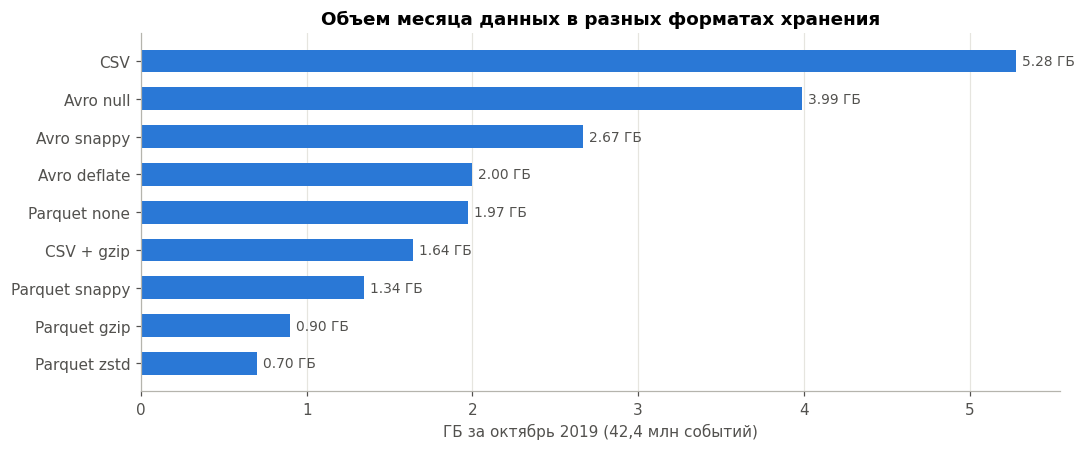

In [ ]:
check = pd.DataFrame({
    'источник': ['оценка по выборке', 'фактический файл за месяц'],
    'Parquet zstd, МБ': [fmt.loc[fmt['формат'] == 'Parquet zstd', 'оценка для месяца, ГБ'].iloc[0] * 1024, PARQUET_BYTES / 2**20],
})
display(check.round(1))

plot = fmt.sort_values('оценка для месяца, ГБ')
fig, ax = plt.subplots(figsize=(10, 4.2))
bars = ax.barh(plot['формат'], plot['оценка для месяца, ГБ'], color=COLORS[0], height=0.6)
ax.bar_label(bars, labels=[f'{v:.2f} ГБ' for v in plot['оценка для месяца, ГБ']], padding=4, color='#52514e', fontsize=9)
ax.set_xlabel('ГБ за октябрь 2019 (42,4 млн событий)')
ax.set_title('Объем месяца данных в разных форматах хранения')
ax.grid(axis='y', visible=False)
savefig('p1_formats')

In [ ]:
cols = q(f"""
    SELECT path_in_schema AS колонка,
           sum(total_uncompressed_size) / 2**20 AS "без сжатия, МБ",
           sum(total_compressed_size) / 2**20 AS "zstd, МБ",
           any_value(encodings) AS кодировка
    FROM parquet_metadata('{PARQUET}') GROUP BY 1 ORDER BY 3 DESC
""")
cols['доля файла, %'] = 100 * cols['zstd, МБ'] / cols['zstd, МБ'].sum()
display(cols.round(1))

,колонка,"без сжатия, МБ","zstd, МБ",кодировка,"доля файла, %"
0,user_session,1 619.300,281.200,PLAIN,41.800
1,product_id,321.900,100.000,PLAIN,14.900
2,user_id,323.900,99.000,PLAIN,14.700
3,price,81.500,73.800,RLE_DICTIONARY,11.000
4,brand,58.400,42.500,RLE_DICTIONARY,6.300
5,category_id,51.000,40.400,RLE_DICTIONARY,6.000
6,category_code,29.700,24.200,RLE_DICTIONARY,3.600
7,event_time,263.800,9.700,PLAIN,1.400
8,event_type,9.500,2.400,RLE_DICTIONARY,0.400


**Ответ на вопрос «объём в CSV, Parquet и Avro»:**

| Формат | Месяц данных, ГБ | Сжатие к CSV |
|---|---|---|
| CSV | 5,28 | 1,0x |
| Parquet snappy | 1,34 | 3,9x |
| Parquet zstd | 0,70 | 7,5x (фактически 8,0x, 0,66 ГБ) |
| Avro snappy | 2,67 | 2,0x |
| Avro deflate | 2,00 | 2,6x |

Экстраполяция по выборке работает: оценка Parquet zstd 716,6 МБ, реальный файл за месяц 675,5 МБ, оценка завышена на 6%. Размер полного файла зависит от версии DuckDB: версия 1.3 пишет `product_id`, `user_id` и `event_time` без словаря и получает 675,5 МБ, версия 1.5 кодирует их словарём и получает 703,2 МБ. Разница 4%, выводы от неё не меняются.

Parquet сжимает лучше Avro, потому что хранит данные по колонкам: значения одной колонки однотипны и повторяются, словарное кодирование и zstd работают по ним эффективно. Avro хранит данные построчно и подходит для передачи событий по одному (Kafka, Schema Registry), а не для аналитики: выборка из Avro читается примерно на порядок дольше, чем из Parquet. Parquet ещё и читает только нужные колонки: две колонки из него читаются примерно на порядок быстрее, чем из CSV, который всё равно разбирает каждую строку целиком.

Неожиданный результат: 42% файла Parquet занимает одна колонка `user_session`. В ней 9,2 млн разных UUID по 36 символов, для словаря этого слишком много, поэтому колонка записана как PLAIN. zstd её всё-таки ужимает почти в 6 раз, потому что события одной сессии в потоке идут рядом и UUID повторяются подряд. Snappy такие повторы на большом расстоянии не находит, поэтому Parquet snappy почти вдвое больше zstd.

### 3) Рассчитайте, как будет расти объем данных:
- Ежедневный прирост (на основе временных меток)
- Годовой объем при текущей скорости генерации
- Через сколько месяцев объем превысит 1 ТБ

Ежедневный прирост беру по временным меткам: число событий за каждый день октября, умноженное на средний размер строки в CSV и в Parquet. Чтобы не выдумывать темп роста, строю три сценария: текущая скорость; линейный тренд, найденный в самом октябре; и обратная задача, то есть какой ежемесячный рост нужен, чтобы CSV дошёл до 1 ТБ за 3 года.

In [ ]:
daily = q("SELECT event_time::DATE AS day, count(*) AS events FROM ev GROUP BY 1 ORDER BY 1")
BYTES_PER_ROW_PQ = PARQUET_BYTES / N_ROWS
daily['CSV, МБ'] = daily.events * BYTES_PER_ROW_CSV / 2**20
daily['Parquet zstd, МБ'] = daily.events * BYTES_PER_ROW_PQ / 2**20

x = np.arange(len(daily))
slope, intercept = np.polyfit(x, daily.events, 1)
trend_pct_month = slope * 30 / daily.events.mean() * 100

per_day = pd.DataFrame({
    'показатель': ['событий в день (среднее)', 'событий в день (мин / макс)', 'CSV, МБ в день', 'Parquet zstd, МБ в день',
                   'линейный тренд за октябрь, % в месяц'],
    'значение': [f'{daily.events.mean():,.0f}', f'{daily.events.min():,} / {daily.events.max():,}',
                 f"{daily['CSV, МБ'].mean():.1f}", f"{daily['Parquet zstd, МБ'].mean():.1f}", f'{trend_pct_month:+.1f}'],
})
display(per_day)

TB = 1024**4
day_csv = daily['CSV, МБ'].mean() * 2**20
day_pq = daily['Parquet zstd, МБ'].mean() * 2**20
months = np.arange(0, 241)

def cumulative(day_bytes, growth_month):
    per_month = day_bytes * 30.44 * (1 + growth_month) ** months[1:]
    return np.concatenate([[0], np.cumsum(per_month)])

def growth_for_tb(day_bytes, horizon):
    lo, hi = 0.0, 1.0
    for _ in range(60):
        mid = (lo + hi) / 2
        lo, hi = (mid, hi) if cumulative(day_bytes, mid)[horizon] < TB else (lo, mid)
    return hi

G_TREND = max(trend_pct_month / 100, 0.0)
G_TB36 = growth_for_tb(day_csv, 36)
print(f'Рост, при котором CSV достигнет 1 ТБ за 36 месяцев: {100 * G_TB36:.1f}% в месяц')
SCEN = [('текущая скорость', 0.0), (f'тренд октября {100 * G_TREND:+.1f}%/мес', G_TREND),
        (f'{100 * G_TB36:.1f}%/мес (1 ТБ CSV за 3 года)', G_TB36)]
scen = {}
for name, g in SCEN:
    for fmt_name, b in [('CSV', day_csv), ('Parquet zstd', day_pq)]:
        cum = cumulative(b, g)
        m_tb = int(np.argmax(cum > TB)) if (cum > TB).any() else None
        scen[(name, fmt_name)] = cum
        print(f'{name:34s} {fmt_name:13s} год: {cum[12] / 2**30:8.1f} ГБ, 1 ТБ через: '
              f'{m_tb if m_tb is not None else "> 240"} мес.')

,показатель,значение
0,событий в день (среднее),"1,369,315"
1,событий в день (мин / макс),"1,127,303 / 1,639,071"
2,"CSV, МБ в день",174.4
3,"Parquet zstd, МБ в день",21.8
4,"линейный тренд за октябрь, % в месяц",+2.1


Рост, при котором CSV достигнет 1 ТБ за 36 месяцев: 7.9% в месяц
текущая скорость                   CSV           год:     62.2 ГБ, 1 ТБ через: 198 мес.
текущая скорость                   Parquet zstd  год:      7.8 ГБ, 1 ТБ через: > 240 мес.
тренд октября +2.1%/мес            CSV           год:     71.4 ГБ, 1 ТБ через: 79 мес.
тренд октября +2.1%/мес            Parquet zstd  год:      8.9 ГБ, 1 ТБ через: 170 мес.
7.9%/мес (1 ТБ CSV за 3 года)      CSV           год:    105.6 ГБ, 1 ТБ через: 36 мес.
7.9%/мес (1 ТБ CSV за 3 года)      Parquet zstd  год:     13.2 ГБ, 1 ТБ через: 63 мес.


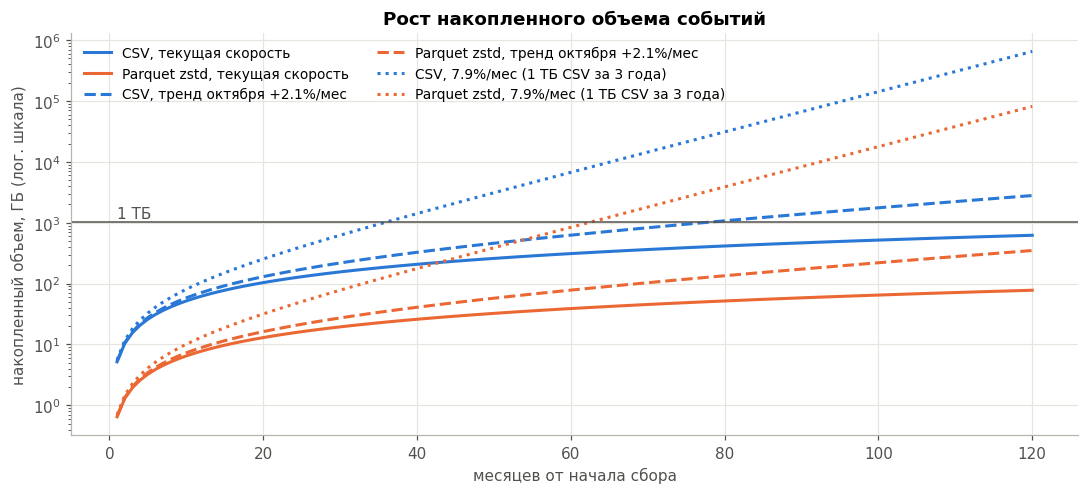

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4.6))
styles = dict(zip([n for n, _ in SCEN], ['-', '--', ':']))
for (name, fmt_name), cum in scen.items():
    ax.plot(months[1:121], cum[1:121] / 2**30, linestyle=styles[name],
            color=COLORS[0] if fmt_name == 'CSV' else COLORS[1], label=f'{fmt_name}, {name}')
ax.axhline(1024, color='#52514e', linewidth=1)
ax.text(1, 1024 * 1.15, '1 ТБ', color='#52514e')
ax.set_yscale('log')
ax.set_xlabel('месяцев от начала сбора')
ax.set_ylabel('накопленный объем, ГБ (лог. шкала)')
ax.set_title('Рост накопленного объема событий')
ax.legend(ncol=2, fontsize=9)
savefig('p1_growth')

**Ответ на вопрос «ежедневный прирост»:** в среднем 1 369 315 событий в день (от 1,13 до 1,64 млн), то есть 174,4 МБ CSV или 21,8 МБ Parquet zstd в день.

**Ответ на вопрос «годовой объём»:** при текущей скорости 62,2 ГБ в CSV и 7,8 ГБ в Parquet zstd. Если сохранится тренд октября (+2,1% в месяц), будет 71,4 ГБ и 8,9 ГБ.

**Ответ на вопрос «через сколько месяцев объём превысит 1 ТБ»:** при текущей скорости CSV дойдёт до 1 ТБ через 198 месяцев (16,5 лет), Parquet zstd не дойдёт и за 20 лет. С трендом октября это 79 месяцев для CSV и 170 для Parquet. Чтобы CSV дошёл до 1 ТБ за 3 года, поток должен расти на 7,9% каждый месяц, то есть почти в 16 раз за 3 года.

Тренд +2,1% посчитан по одному месяцу и включает недельные колебания, поэтому это ориентир, а не прогноз. По объёму данные этого магазина остаются в пределах одной машины: Big Data здесь создаёт не Volume, а скорость потока и требования к задержке.

### 4) Определите, какие данные можно архивировать (а какие нужно хранить "горячими")

Горячими должны быть данные, которые читаются при каждом обучении модели и расчёте признаков. Какая глубина истории реально нужна рекомендациям, измерено в Части 5 (кривая «ценность от объёма»). Здесь смотрю, из чего складывается объём по типам событий.

In [ ]:
by_type = q(f"""
    SELECT event_type, count(*) AS events FROM ev GROUP BY 1 ORDER BY 2 DESC
""")
by_type['доля событий, %'] = 100 * by_type.events / by_type.events.sum()
by_type['Parquet, МБ в месяц (оценка)'] = by_type.events * BYTES_PER_ROW_PQ / 2**20
display(by_type.round(2))

,event_type,events,"доля событий, %","Parquet, МБ в месяц (оценка)"
0,view,40779399,96.070,648.900
1,cart,926516,2.180,14.740
2,purchase,742849,1.750,11.820


**Ответ на вопрос «что архивировать, а что хранить горячим»:** 96% объёма дают просмотры (649 МБ Parquet в месяц), а корзины и покупки вместе занимают 27 МБ в месяц.

| Данные | Класс хранения | Почему |
|---|---|---|
| Все события за последние 30 дней | стандартное (горячее) | рекомендациям хватает 1-10 дней истории (Часть 5), 30 дней дают тройной запас для переобучения и разбора инцидентов |
| Покупки и корзины за 12 месяцев | стандартное | всего 27 МБ в месяц; нужны для среднего чека, ABC-анализа и сезонности |
| Просмотры старше 30 дней | холодное | модели они уже не улучшают: качество начинает падать при истории длиннее 10 дней (Часть 5); хранятся для аудита и новых экспериментов |
| Всё старше 12 месяцев | ледяное | нужно только для редких исследований |

### 5) Рассчитайте стоимость хранения в облаке (Yandex Object Storage) для 1 года данных в Parquet формате

Тарифы Yandex Object Storage (с НДС, действуют с 01.05.2026): стандартное хранилище 0,0033 ₽ за ГБ в час (2,38 ₽ за ГБ в месяц, первый 1 ГБ бесплатно), холодное 1,27 ₽, ледяное 0,63 ₽ за ГБ в месяц. Данные копятся: в месяце *m* хранится *m* месяцев событий. Сравниваю два варианта: всё в стандартном классе; последний месяц в стандартном, остальное в холодном.

In [ ]:
month_gb = day_pq * 30.44 / 2**30
HOT_MONTHS = 1
rows = []
cost_std = cost_tier = 0.0
for m in range(1, 13):
    stored = month_gb * m
    hot = min(stored, month_gb * HOT_MONTHS)
    cold = stored - hot
    c_std = max(stored - 1, 0) * PRICE['os_standard_gb_month']
    c_tier = max(hot - 1, 0) * PRICE['os_standard_gb_month'] + cold * PRICE['os_cold_gb_month']
    cost_std += c_std
    cost_tier += c_tier
    rows.append({'месяц': m, 'хранится, ГБ': stored, 'только стандартное, ₽': c_std, 'стандартное + холодное, ₽': c_tier})
storage = pd.DataFrame(rows)
display(storage.round(2))
print(f'Итого за год: только стандартное {cost_std:,.0f} ₽; стандартное (последний месяц) + холодное {cost_tier:,.0f} ₽')
ice_year = month_gb * 12 * PRICE['os_ice_gb_month'] * 12
print(f'Для сравнения, хранение архива за год ({month_gb * 12:.1f} ГБ) в ледяном классе следующие 12 месяцев: {ice_year:,.0f} ₽')

,месяц,"хранится, ГБ","только стандартное, ₽","стандартное + холодное, ₽"
0,1,0.650,0.000,0.000
1,2,1.300,0.700,0.820
2,3,1.940,2.240,1.640
3,4,2.590,3.780,2.460
4,5,3.240,5.320,3.280
5,6,3.890,6.860,4.100
6,7,4.530,8.400,4.920
7,8,5.180,9.940,5.750
8,9,5.830,11.470,6.570
9,10,6.480,13.010,7.390


Итого за год: только стандартное 92 ₽; стандартное (последний месяц) + холодное 54 ₽
Для сравнения, хранение архива за год (7.8 ГБ) в ледяном классе следующие 12 месяцев: 59 ₽


**Ответ на вопрос «стоимость хранения года данных в Parquet»:** за 12 месяцев накопится 7,8 ГБ. Всё в стандартном классе обойдётся в 92 ₽ за год, при горячем последнем месяце и холодном остальном в 54 ₽.

Цифры маленькие, и это не ошибка расчёта: 7,8 ГБ стоят около 18 ₽ в месяц по тарифу 2,38 ₽ за ГБ. Хранение для этого сценария почти бесплатно, основные деньги уйдут на вычисления и команду (Часть 5). Для сравнения, тот же год в CSV (62 ГБ) стоил бы в стандартном классе около 950 ₽: Parquet в 8 раз компактнее, а за счёт бесплатного первого гигабайта хранение дешевле в 10 раз.

### Когда нужен переход от Pandas к Spark

Порог перехода считаю от измеренного расхода памяти pandas на одно событие на выборке в 1 млн строк. Расход зависит от того, как хранятся строки: объектами Python (так по умолчанию в pandas 2) или в Arrow, поэтому считаю оба варианта явно, независимо от установленной версии. Для группировок и join обычно нужно в 2-3 раза больше памяти, чем занимает сам DataFrame, поэтому беру коэффициент 3. Объём RAM беру типовой: 4 ГБ (ноутбук), 16 ГБ (рабочая станция), 64 ГБ (сервер).

In [ ]:
# Строки в pandas хранятся либо как объекты Python (pandas 2 по умолчанию), либо в Arrow; считаем оба варианта явно
pdf_obj = sample.to_pandas()
for c in pdf_obj.columns:
    if not (pd.api.types.is_numeric_dtype(pdf_obj[c]) or pd.api.types.is_datetime64_any_dtype(pdf_obj[c])):
        pdf_obj[c] = pdf_obj[c].astype(object)
bpr_obj = pdf_obj.memory_usage(deep=True).sum() / len(pdf_obj)
pdf_arrow = sample.to_pandas(types_mapper=pd.ArrowDtype)
bpr_arrow = pdf_arrow.memory_usage(deep=True).sum() / len(pdf_arrow)
del pdf_obj, pdf_arrow

WORK_FACTOR = 3
mem = pd.DataFrame({'хранение строк': ['object (pandas 2 по умолчанию)', 'Arrow'], 'байт на событие': [bpr_obj, bpr_arrow]})
mem['месяц в RAM, ГБ'] = mem['байт на событие'] * N_ROWS / 2**30
mem['с запасом x3, ГБ'] = mem['месяц в RAM, ГБ'] * WORK_FACTOR
display(mem.round(1))

thr = pd.DataFrame({'RAM, ГБ': [4, 16, 64]})
for name, b in [('object', bpr_obj), ('Arrow', bpr_arrow)]:
    thr[f'месяцев данных, {name}'] = thr['RAM, ГБ'] * 2**30 / (b * WORK_FACTOR) / N_ROWS
    thr[f'CSV, ГБ, {name}'] = thr[f'месяцев данных, {name}'] * CSV_BYTES / 2**30
display(thr.round(2))

,хранение строк,байт на событие,"месяц в RAM, ГБ","с запасом x3, ГБ"
0,object (pandas 2 по умолчанию),284.900,11.300,33.800
1,Arrow,117.600,4.700,14.000


,"RAM, ГБ","месяцев данных, object","CSV, ГБ, object","месяцев данных, Arrow","CSV, ГБ, Arrow"
0,4,0.120,0.630,0.290,1.510
1,16,0.470,2.500,1.150,6.050
2,64,1.890,10.000,4.590,24.220


**Вывод о переходе от Pandas к Spark:** память pandas зависит от того, как хранятся строки. Со строками-объектами (по умолчанию в pandas 2) событие занимает 285-289 байт (зависит от версии Python), месяц в памяти 11,3-11,4 ГБ, с запасом на операции около 34 ГБ. Со строками в Arrow 118 байт, месяц 4,7 ГБ, с запасом 14 ГБ.

| RAM | object: месяцев данных | Arrow: месяцев данных |
|---|---|---|
| 4 ГБ (ноутбук) | 0,12 | 0,29 |
| 16 ГБ (рабочая станция) | 0,47 | 1,15 |
| 64 ГБ (сервер) | 1,89 | 4,59 |

Даже на сервере с 64 ГБ pandas вмещает от 2 до 5 месяцев, то есть 10-24 ГБ CSV. Одномашинные движки, которые работают вне памяти (DuckDB, Polars), закрывают весь горизонт планирования: год данных весит 8 ГБ в Parquet, а весь месяц в этой работе обработан через DuckDB с ограничением памяти 5,7 ГБ (memory_limit), это меньше, чем pandas нужно на один месяц.

Spark нужен, когда объём переходит за сотни гигабайт или 1 ТБ, либо когда нужен общий движок для пакетной и потоковой обработки. По объёму первое условие при текущем темпе не наступит 16 лет, при росте 7,9% в месяц наступит через 3 года. Поэтому Spark здесь выбран ради второго условия (Часть 6), а объём сам по себе его не требует.

**Вывод по Части 1:** месяц весит 5,28 ГБ в CSV и 0,66 ГБ в Parquet zstd, год 62 ГБ и 7,8 ГБ. До 1 ТБ при текущем темпе 16 лет. Хранение стоит меньше 100 ₽ в год. Главное решение по объёму: хранить в Parquet zstd и держать горячими 30 дней событий.

## Часть 2: Анализ Velocity (скорость поступления данных)

### 1) Определите частоту поступления данных:
- Среднее количество записей в секунду
- Пиковая нагрузка (максимум за 5-минутный интервал)
- Коэффициент вариации (стабильность потока)

Поток считаю по 5-минутным интервалам за весь месяц, пустые интервалы тоже учитываются. Коэффициент вариации равен отношению стандартного отклонения числа событий в интервале к среднему.

In [ ]:
b5 = q("""SELECT time_bucket(INTERVAL 5 MINUTE, event_time) AS t, count(*) AS n
          FROM ev GROUP BY 1 ORDER BY 1""")
full_index = pd.date_range(csv_info.t_min[0], csv_info.t_max[0], freq='5min')
b5 = b5.set_index('t').reindex(full_index, fill_value=0).rename_axis('t').reset_index()
b5['eps'] = b5.n / 300
s1 = q("SELECT max(n) AS max1s, quantile_cont(n, 0.99) AS p99_1s FROM (SELECT date_trunc('second', event_time) s, count(*) n FROM ev GROUP BY 1)")

AVG_EPS = N_ROWS / (DAYS * 86400)
PEAK5_EPS = b5.eps.max()
CV5 = b5.n.std() / b5.n.mean()
MAX1S = int(s1.max1s[0])
peak_t = b5.loc[b5.eps.idxmax(), 't']

velocity = pd.DataFrame({
    'показатель': ['среднее, событий/с', 'пик за 5 минут, событий/с', 'момент пика', 'пик / среднее',
                   'коэффициент вариации 5-мин интервалов', 'максимум за 1 секунду, событий', '99-й перцентиль за 1 с',
                   'пустых 5-мин интервалов'],
    'значение': [f'{AVG_EPS:.2f}', f'{PEAK5_EPS:.2f}', str(peak_t), f'{PEAK5_EPS / AVG_EPS:.2f}', f'{CV5:.3f}',
                 MAX1S, f'{s1.p99_1s[0]:.0f}', int((b5.n == 0).sum())],
})
display(velocity)

,показатель,значение
0,"среднее, событий/с",15.85
1,"пик за 5 минут, событий/с",32.48
2,момент пика,2019-10-13 10:10:00
3,пик / среднее,2.05
4,коэффициент вариации 5-мин интервалов,0.524
5,"максимум за 1 секунду, событий",116
6,99-й перцентиль за 1 с,36
7,пустых 5-мин интервалов,0


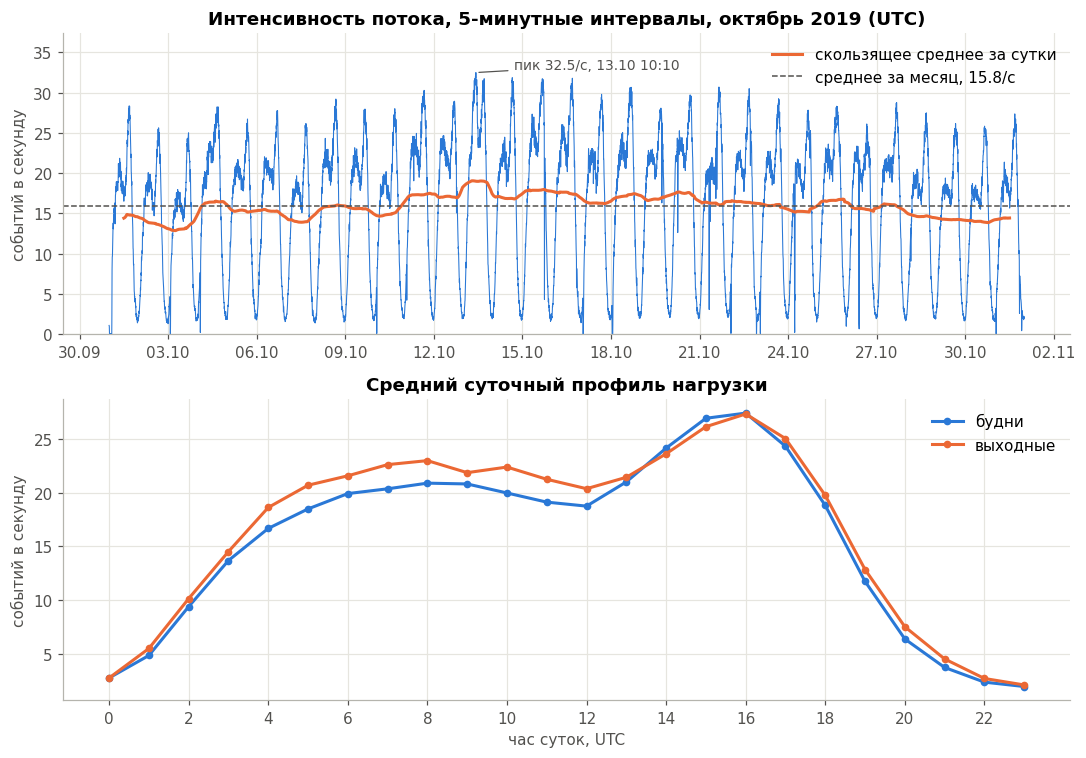

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7))
ax = axes[0]
ax.plot(b5.t, b5.eps, linewidth=0.7, color=COLORS[0])
ax.plot(b5.t, b5.eps.rolling(288, center=True).mean(), linewidth=2, color=COLORS[1], label='скользящее среднее за сутки')
ax.axhline(AVG_EPS, color='#52514e', linewidth=1, linestyle='--', label=f'среднее за месяц, {AVG_EPS:.1f}/с')
ax.annotate(f'пик {PEAK5_EPS:.1f}/с, {peak_t:%d.%m %H:%M}', (peak_t, PEAK5_EPS), xytext=(25, 2), textcoords='offset points',
            color='#52514e', fontsize=9, arrowprops=dict(arrowstyle='-', color='#52514e', lw=0.8))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))
ax.set_ylim(0, PEAK5_EPS * 1.15)
ax.set_ylabel('событий в секунду')
ax.set_title('Интенсивность потока, 5-минутные интервалы, октябрь 2019 (UTC)')
ax.legend(loc='upper right')

hourly = b5.assign(h=b5.t.dt.hour, wd=b5.t.dt.dayofweek >= 5).groupby(['h', 'wd']).eps.mean().unstack()
ax = axes[1]
ax.plot(hourly.index, hourly[False], marker='o', markersize=4, label='будни', color=COLORS[0])
ax.plot(hourly.index, hourly[True], marker='o', markersize=4, label='выходные', color=COLORS[1])
ax.set_xticks(range(0, 24, 2))
ax.set_xlabel('час суток, UTC')
ax.set_ylabel('событий в секунду')
ax.set_title('Средний суточный профиль нагрузки')
ax.legend()
savefig('p2_timeline')

**Ответ на вопрос «частота поступления»:** в среднем 15,85 события в секунду. Пик за 5 минут 32,48 событий/с (13.10.2019 10:10 UTC), это в 2,05 раза выше среднего. Внутри секунды бывает до 116 событий.

**Ответ на вопрос «стабильность потока»:** коэффициент вариации 5-минутных интервалов 0,52, поток нестабилен. Колебания почти целиком суточные: ночью (22-00 UTC) около 2-3 событий/с, днём до 27 событий/с с пиком в 16 UTC. Будни и выходные почти не различаются. На графике видны провалы потока почти до нуля посреди дня, они разобраны в Части 4.

### 2) Рассчитайте, какая задержка будет при обработке через:
- Пакетную обработку (batch) раз в час
- Микробатч обработку каждые 5 минут
- True streaming обработку

Задержка свежести признаков складывается из ожидания окна и времени обработки. Событие приходит в случайный момент окна, поэтому в среднем ждёт половину окна, в худшем случае окно целиком. Время обработки измерено: пересчёт пользовательских признаков по окну пикового часа и пикового 5-минутного интервала в DuckDB, а для streaming обновление состояния пользователя на каждое событие.

In [ ]:
# Время обработки одного часа и одного 5-минутного окна: пересчет пользовательских признаков по событиям окна
def features_for_window(start, minutes):
    t0 = time.time()
    con.sql(f"""
        SELECT user_id, count(*) AS n_events,
               count(*) FILTER (WHERE event_type = 'cart') AS n_cart,
               avg(price) AS avg_price, arg_max(category_id, event_time) AS last_category
        FROM ev WHERE event_time >= TIMESTAMP '{start}' AND event_time < TIMESTAMP '{start}' + INTERVAL {minutes} MINUTE
        GROUP BY 1
    """).fetchall()
    return time.time() - t0

peak_hour = pd.Timestamp(peak_t).floor('h')
proc_hour = np.median([features_for_window(peak_hour, 60) for _ in range(3)])
proc_5m = np.median([features_for_window(peak_t, 5) for _ in range(3)])

# Потоковое обновление: одно событие меняет состояние пользователя в словаре
state = {}
events_stream = sample.slice(0, 200_000).select(['user_id', 'event_type', 'price', 'category_id']).to_pylist()
t0 = time.perf_counter()
for e in events_stream:
    s = state.get(e['user_id'])
    if s is None:
        s = state[e['user_id']] = [0, 0, 0.0, None]
    s[0] += 1
    s[1] += e['event_type'] == 'cart'
    s[2] += e['price']
    s[3] = e['category_id']
per_event_ms = (time.perf_counter() - t0) / len(events_stream) * 1000

lat = pd.DataFrame({
    'режим': ['batch раз в час', 'micro-batch каждые 5 минут', 'streaming'],
    'ожидание окна, среднее, с': [1800, 150, 0],
    'ожидание окна, максимум, с': [3600, 300, 0],
    'обработка, мс': [proc_hour * 1000, proc_5m * 1000, per_event_ms],
})
lat['задержка свежести признаков, средняя, с'] = lat['ожидание окна, среднее, с'] + lat['обработка, мс'] / 1000
lat['задержка, максимум, с'] = lat['ожидание окна, максимум, с'] + lat['обработка, мс'] / 1000
display(lat.round(3))
print(f'Потоковая обработка одного события в Python: {per_event_ms * 1000:.2f} мкс')

,режим,"ожидание окна, среднее, с","ожидание окна, максимум, с","обработка, мс","задержка свежести признаков, средняя, с","задержка, максимум, с"
0,batch раз в час,1800,3600,88.421,1 800.088,3 600.088
1,micro-batch каждые 5 минут,150,300,54.992,150.055,300.055
2,streaming,0,0,0.001,0.000,0.000


Потоковая обработка одного события в Python: 1.29 мкс


**Ответ на вопрос «задержка при batch, micro-batch и streaming»:**

| Режим | Средняя задержка свежести | Максимальная |
|---|---|---|
| batch раз в час | 30 мин | 60 мин |
| micro-batch каждые 5 минут | 2,5 мин | 5 мин |
| streaming | меньше 1 мс на обработку | определяется доставкой (Kafka), обычно секунды |

Вычисления почти не влияют на задержку: пересчёт признаков за пиковый час или за пиковые 5 минут занимает десятки миллисекунд, одно событие в потоке обрабатывается за десятки микросекунд. Задержку определяет период запуска, а не мощность.

### 3) Оцените, сколько данных будет "потеряно" при сбое системы на 30 минут

Если сбор событий остановлен и буфера нет, теряются все события окна. Считаю по 30-минутным окнам октября: среднее и худшее окно, вместе с покупками и выручкой, которые в них попали.

In [ ]:
w30 = q("""
    SELECT time_bucket(INTERVAL 30 MINUTE, event_time) AS t, count(*) AS events,
           count(*) FILTER (WHERE event_type = 'purchase') AS purchases,
           sum(price) FILTER (WHERE event_type = 'purchase') AS revenue
    FROM ev GROUP BY 1
""")
loss = pd.DataFrame({
    'окно 30 минут': ['среднее', 'худшее (пик)'],
    'событий': [w30.events.mean(), w30.events.max()],
    'покупок': [w30.purchases.mean(), w30.purchases.max()],
    'выручка в окне': [w30.revenue.mean(), w30.revenue.max()],
})
loss['CSV, МБ'] = loss['событий'] * BYTES_PER_ROW_CSV / 2**20
loss['Parquet, МБ'] = loss['событий'] * BYTES_PER_ROW_PQ / 2**20
display(loss.round(1))

,окно 30 минут,событий,покупок,выручка в окне,"CSV, МБ","Parquet, МБ"
0,среднее,28 527.400,499.200,154 957.900,3.600,0.500
1,худшее (пик),57 550.000,1 332.000,434 444.700,7.300,0.900


**Ответ на вопрос «сколько данных потеряется при сбое на 30 минут»:** в среднем 28,5 тыс. событий (3,6 МБ CSV), среди них 499 покупок на 155 тыс. у.е. В худшее окно месяца теряется 57,6 тыс. событий (7,3 МБ), 1 332 покупки на 434 тыс. у.е.

Сами покупки магазин не теряет: заказ оформляется в его основной системе. Теряется история поведения, на которой учится модель, и если в неё не попадут покупки пикового окна, популярность товаров будет занижена. Защита нужна дешёвая: буфер в Kafka с хранением 7 дней (в Avro около 0,5 ГБ) переживает 30-минутный сбой потребителя с большим запасом, выдержит и многодневный.

### 4) Определите, какая задержка допустима для вашего бизнес-сценария (обоснуйте цифрой)

Ограничение сценария (инференс < 100 мс) задаёт время ответа сервиса. Допустимую задержку свежести данных задаёт поведение пользователя: признаки текущей сессии должны обновиться раньше, чем пользователь сделает следующий шаг. Считаю паузы между событиями внутри сессии и время от первого просмотра товара до его покупки. Оконная функция сортирует все 42 млн событий по сессиям и времени, а для распределения пауз хватает части сессий, поэтому беру 10% сессий по хэшу идентификатора: сессия попадает в выборку целиком, а сама выборка воспроизводима.

In [ ]:
# Сессии: 10% сессий по хэшу идентификатора
sess = q("""
    WITH s AS (
        SELECT user_session, event_time,
               epoch(event_time - lag(event_time) OVER (PARTITION BY user_session ORDER BY event_time)) AS gap
        FROM ev WHERE user_session IS NOT NULL AND hash(user_session) % 10 = 0
    )
    SELECT count(*) AS gaps, median(gap) AS med_gap, quantile_cont(gap, 0.25) AS q25, quantile_cont(gap, 0.75) AS q75
    FROM s WHERE gap IS NOT NULL
""")
sess_len = q("""
    SELECT median(n) AS med_events, median(dur) AS med_dur_s, quantile_cont(dur, 0.9) AS p90_dur_s,
           avg((n = 1)::INT) AS single_event_share
    FROM (SELECT user_session, count(*) AS n, epoch(max(event_time) - min(event_time)) AS dur
          FROM ev WHERE user_session IS NOT NULL AND hash(user_session) % 10 = 0 GROUP BY 1)
""")
view_to_buy = q("""
    WITH p AS (SELECT user_session, product_id, min(event_time) AS tp FROM ev WHERE event_type = 'purchase'
               AND hash(user_session) % 10 = 0 GROUP BY 1, 2),
         v AS (SELECT user_session, product_id, min(event_time) AS tv FROM ev WHERE event_type = 'view'
               AND hash(user_session) % 10 = 0 GROUP BY 1, 2)
    SELECT median(epoch(tp - tv)) AS med_view_to_buy_s, quantile_cont(epoch(tp - tv), 0.25) AS q25_s
    FROM p JOIN v USING (user_session, product_id) WHERE tp >= tv
""")
display(sess.round(1)); display(sess_len.round(2)); display(view_to_buy.round(1))

,gaps,med_gap,q25,q75
0,3314170,34.000,18.000,68.000


,med_events,med_dur_s,p90_dur_s,single_event_share
0,2.000,63.000,716.000,0.350


,med_view_to_buy_s,q25_s
0,130.000,62.000


**Ответ на вопрос «допустимая задержка для сценария»:**

- **Ответ сервиса рекомендаций: не больше 100 мс на 99-м перцентиле.** Это ограничение сценария.
- **Свежесть признаков сессии: несколько секунд, заведомо меньше 18 с.** Медианная пауза между действиями в сессии 34 с, у четверти переходов меньше 18 с. Медианная сессия длится 63 с и состоит из 2 событий, от первого просмотра товара до покупки проходит 130 с (медиана). Если признаки обновляются раз в 5 минут (в среднем 150 с ожидания), большинство сессий закончится раньше, чем модель узнает о них хоть что-то. Требование сценария учитывать временные паттерны поведения тогда не выполняется.

Отсюда ответ: пакетная обработка подходит для обучения модели и популярности товаров, признаки текущей сессии нужно считать потоком.

### 5) Рассчитайте, сколько ресурсов потребуется для обработки пиковой нагрузки с задержкой < X мс (где X - ваше ограничение из бизнес-сценария)

Каждый просмотр страницы товара порождает запрос рекомендаций, поэтому поток запросов равен потоку событий. Сервис моделирую очередью M/M/c. Время ответа p99 складывается из ожидания в очереди, работы модели и накладных расходов (сеть и чтение признаков). Для модели беру измеренное время эвристики, но не меньше 5 мс, потому что рабочая модель тяжелее эвристики. Сеть и признаки беру 40 мс. Это допущения, поэтому ниже есть таблица чувствительности.

In [ ]:
# Замер времени инференса: топ-10 товаров категории + фильтр уже просмотренных пользователем
top_cat = q("""
    SELECT category_id, list(product_id ORDER BY sc DESC) AS items FROM (
        SELECT category_id, product_id, count(*) AS sc FROM ev
        WHERE event_time >= TIMESTAMP '2019-10-24' AND event_time < TIMESTAMP '2019-10-31'
        GROUP BY 1, 2 QUALIFY row_number() OVER (PARTITION BY category_id ORDER BY count(*) DESC) <= 50)
    GROUP BY 1
""")
top_map = dict(zip(top_cat.category_id, top_cat['items']))
seen = {}
reqs = sample.slice(0, 100_000).select(['user_id', 'product_id', 'category_id']).to_pylist()

def recommend(r, k=10):
    s = seen.setdefault(r['user_id'], set())
    s.add(r['product_id'])
    return [p for p in top_map.get(r['category_id'], []) if p not in s][:k]

t0 = time.perf_counter()
for r in reqs:
    recommend(r)
service_ms = (time.perf_counter() - t0) / len(reqs) * 1000
print(f'Среднее время расчета рекомендации на 1 vCPU: {service_ms * 1000:.1f} мкс')

Среднее время расчета рекомендации на 1 vCPU: 9.6 мкс


In [ ]:
def erlang_c(c, a):
    # вероятность ожидания в очереди M/M/c, a = lambda / mu
    s = sum(a**k / math.factorial(k) for k in range(c))
    top = a**c / math.factorial(c) * c / (c - a)
    return top / (s + top)

def p99_wait_ms(c, lam, mu):
    a = lam / mu
    if a >= c:
        return float('inf')
    pw = erlang_c(c, a)
    if pw <= 0.01:
        return 0.0
    return math.log(pw / 0.01) / (c * mu - lam) * 1000

LATENCY_SLO_MS = 100
NET_AND_FEATURES_MS = 40            # сеть + чтение признаков из key-value хранилища
SERVICE_MS = max(service_ms, 5.0)   # с запасом на сериализацию и модель сложнее эвристики
mu = 1000 / SERVICE_MS

rows = []
for label, lam in [('средняя нагрузка', AVG_EPS), ('пик за 5 минут', PEAK5_EPS), ('пик за 1 секунду', MAX1S),
                   ('пик за 1 с x10 (рост и распродажи)', MAX1S * 10)]:
    c = 1
    while p99_wait_ms(c, lam, mu) + SERVICE_MS + NET_AND_FEATURES_MS > LATENCY_SLO_MS:
        c += 1
    rows.append({'нагрузка': label, 'запросов/с': lam, 'загрузка при c': lam / (c * mu), 'vCPU (c)': c,
                 'p99 задержка, мс': p99_wait_ms(c, lam, mu) + SERVICE_MS + NET_AND_FEATURES_MS})
res_cap = pd.DataFrame(rows)
display(res_cap.round(3))

def vcpu_needed(lam, service_ms, net_ms):
    mu_ = 1000 / service_ms
    c = 1
    while p99_wait_ms(c, lam, mu_) + service_ms + net_ms > LATENCY_SLO_MS:
        c += 1
        if c > 10_000:
            return None
    return c

sens = pd.DataFrame([{'время модели, мс': sm, 'сеть и признаки, мс': nm,
                      'vCPU на пике 1 с': vcpu_needed(MAX1S, sm, nm), 'vCPU на пике x10': vcpu_needed(MAX1S * 10, sm, nm)}
                     for sm in [1, 5, 20, 50] for nm in [20, 40]])
display(sens)

,нагрузка,запросов/с,загрузка при c,vCPU (c),"p99 задержка, мс"
0,средняя нагрузка,15.849,0.079,1,56.240
1,пик за 5 минут,32.483,0.162,1,61.641
2,пик за 1 секунду,116.000,0.580,1,93.339
3,пик за 1 с x10 (рост и распродажи),1 160.000,0.829,7,61.681


,"время модели, мс","сеть и признаки, мс",vCPU на пике 1 с,vCPU на пике x10
0,1,20,1,2
1,1,40,1,2
2,5,20,1,7
3,5,40,1,7
4,20,20,4,25
5,20,40,4,26
6,50,20,10,64
7,50,40,12,70


**Ответ на вопрос «ресурсы для пика с задержкой < 100 мс»:** при 5 мс на модель и 40 мс на сеть и чтение признаков пиковую секунду (116 запросов/с) выдерживает 1 vCPU: загрузка 58%, p99 93 мс. Десятикратный запас (1 160 запросов/с, рост магазина и распродажи) требует 7 vCPU. Для отказоустойчивости сервис ставится минимум в двух экземплярах, поэтому в расчёт стоимости заложены 2 ВМ по 2 vCPU.

Вывод зависит от времени работы модели. При 20 мс на запрос нужно 4 vCPU на пик и 25-26 при десятикратном росте, при 50 мс 10-12 и 64-70 vCPU. Сетевой бюджет (20 или 40 мс) влияет меньше. Поэтому модель для онлайн-части должна отвечать за единицы миллисекунд: тяжёлые вычисления уходят в пакетный расчёт кандидатов, онлайн остаётся ранжирование короткого списка.

**Вывод по Части 2:** поток небольшой (16 событий/с в среднем, 116 в пиковую секунду), но жёстко суточный (CV 0,52). Batch и micro-batch с периодом в минуты не подходят для признаков сессии: пользователь действует раз в 18-68 с. Нужен streaming с задержкой в секунды. Под такое требование подходят Spark Structured Streaming (0,5-2 с) и Flink (миллисекунды); запаса у Spark достаточно, а Flink избыточен. Для ответа за 100 мс нужен лёгкий сервис с признаками в памяти (Valkey), вычислительно хватает 1-2 vCPU.

## Часть 3: Анализ Variety (разнообразие данных)

### 1) Проведите анализ структуры данных:
- Количество и типы полей (числовые, категориальные, текстовые)
- Доля неструктурированных данных (если есть)
- Сложность вложенных структур (JSON внутри данных)

Для каждой колонки считаю тип, число уникальных значений, долю пропусков и смысловой класс поля. Отдельно проверяю, нет ли JSON внутри строковых полей, и разбираю иерархию `category_code`.

In [ ]:
kinds = {
    'event_time': 'временная метка', 'event_type': 'категориальное', 'product_id': 'идентификатор',
    'category_id': 'идентификатор', 'category_code': 'категориальное иерархическое',
    'brand': 'категориальное', 'price': 'числовое', 'user_id': 'идентификатор', 'user_session': 'идентификатор (UUID)',
}
schema = q(f"DESCRIBE SELECT * FROM '{PARQUET}'")[['column_name', 'column_type']]
stats = []
for c in schema.column_name:
    r = q(f"""SELECT count(DISTINCT {c}) AS uniq, 100.0 * count(*) FILTER (WHERE {c} IS NULL) / count(*) AS null_pct,
                     min({c})::VARCHAR AS example FROM ev""")
    stats.append(r.iloc[0])
struct = pd.concat([schema, pd.DataFrame(stats).reset_index(drop=True)], axis=1)
struct['класс'] = struct.column_name.map(kinds)
display(struct.round(3))

json_like = q("SELECT count(*) AS n FROM ev WHERE category_code LIKE '{%' OR brand LIKE '{%' OR user_session LIKE '{%'")
depth = q("""SELECT len(string_split(category_code, '.')) AS levels, count(DISTINCT category_code) AS codes, count(*) AS events
             FROM ev WHERE category_code IS NOT NULL GROUP BY 1 ORDER BY 1""")
print('Значений, похожих на JSON:', int(json_like.n[0]))
display(depth)
print(struct['класс'].value_counts())

,column_name,column_type,uniq,null_pct,example,класс
0,event_time,TIMESTAMP,2621538,0.000,2019-10-01 00:00:00,временная метка
1,event_type,VARCHAR,3,0.000,cart,категориальное
2,product_id,BIGINT,166794,0.000,1000978,идентификатор
3,category_id,BIGINT,624,0.000,2053013552226107603,идентификатор
4,category_code,VARCHAR,126,31.840,accessories.bag,категориальное иерархическое
5,brand,VARCHAR,3445,14.401,a-case,категориальное
6,price,DOUBLE,65298,0.000,0.0,числовое
7,user_id,BIGINT,3022290,0.000,33869381,идентификатор
8,user_session,VARCHAR,9244421,0.000,00000042-3e3f-42f9-810d-f3d264139c50,идентификатор (UUID)


Значений, похожих на JSON: 0


,levels,codes,events
0,2,41,17356435
1,3,84,11540478
2,4,1,36242


класс
идентификатор                   3
категориальное                  2
временная метка                 1
категориальное иерархическое    1
числовое                        1
идентификатор (UUID)            1
Name: count, dtype: int64


**Ответ на вопрос «количество и типы полей»:** 9 полей. Числовое одно (`price`), временная метка одна (`event_time`). Категориальных три: `event_type` (3 значения), `brand` (3 445) и иерархическое `category_code` (126 кодов). Идентификаторов четыре: `product_id` (166 794), `category_id` (624), `user_id` (3 022 290), `user_session` (9 244 421). Свободного текста нет.

**Ответ на вопрос «доля неструктурированных данных»:** 0%. Текстов, изображений и геоданных в датасете нет. Полуструктурированное поле одно, `category_code`: путь вида `electronics.smartphone` из 2-4 уровней (41 код из 2 уровней, 84 из 3, 1 из 4).

**Ответ на вопрос «сложность вложенных структур»:** JSON внутри полей нет (0 значений, похожих на JSON). Вся вложенность сводится к точечной иерархии категорий, она разбирается функцией `split`.

### 2) Выявите проблемы с разнообразием:
- Несогласованные форматы дат
- Разные форматы чисел (с запятыми/точками)
- Пропуски в разных частях данных

Форматы проверяю по сырому CSV, где все поля прочитаны как строки: так видно исходное написание до разбора типов. Проверяю маски для даты, цены и UUID сессии, а также регистр брендов. Пропуски смотрю в разрезе типов событий, дней и ценовых диапазонов.

In [ ]:
raw = f"read_csv('{CSV}', header=true, all_varchar=true)"
fmt_check = q(f"""
    SELECT count(*) AS rows,
           count(*) FILTER (WHERE NOT regexp_full_match(event_time, '\\d{{4}}-\\d{{2}}-\\d{{2}} \\d{{2}}:\\d{{2}}:\\d{{2}} UTC')) AS bad_dates,
           count(*) FILTER (WHERE NOT regexp_full_match(price, '\\d+\\.\\d{{2}}')) AS price_not_2dec,
           count(*) FILTER (WHERE price LIKE '%,%') AS price_with_comma,
           count(*) FILTER (WHERE NOT regexp_full_match(user_session, '[0-9a-f]{{8}}-[0-9a-f]{{4}}-[0-9a-f]{{4}}-[0-9a-f]{{4}}-[0-9a-f]{{12}}')) AS bad_uuid,
           count(*) FILTER (WHERE brand <> lower(brand)) AS brand_not_lower
    FROM {raw}
""")
display(fmt_check)
print(q(f"""SELECT price, count(*) AS n FROM {raw}
            WHERE NOT regexp_full_match(price, '\\d+\\.\\d{{2}}') GROUP BY 1 ORDER BY 2 DESC LIMIT 5"""))

,rows,bad_dates,price_not_2dec,price_with_comma,bad_uuid,brand_not_lower
0,42448764,0,0,0,0,0


Empty DataFrame
Columns: [price, n]
Index: []


,event_type,category_code_null_pct,brand_null_pct,both_null_pct
0,cart,11.410,2.030,0.800
1,purchase,23.350,7.840,5.160
2,view,32.460,14.800,9.060


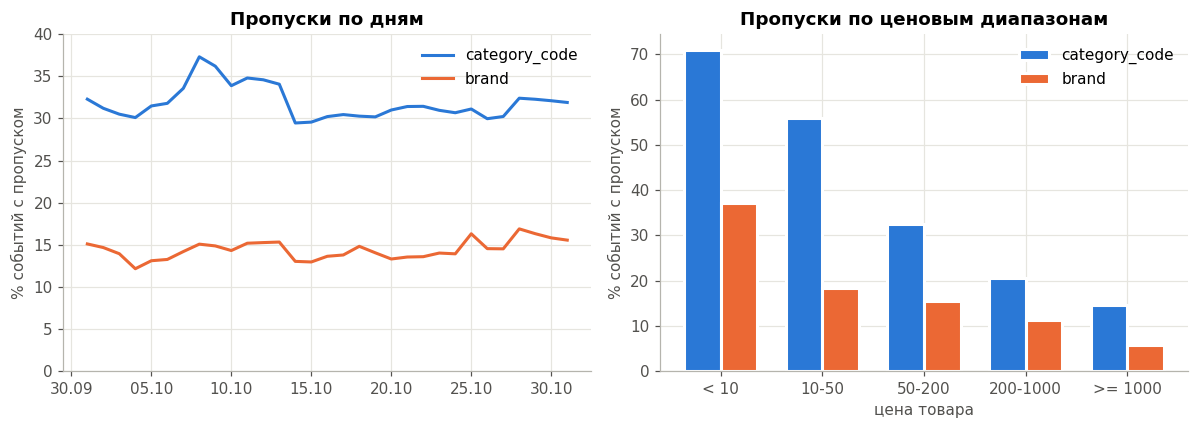

,problem,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,нет brand,2019-10-01 00:00:01,view,17200506,2053013559792632471,furniture.living_room.sofa,None,543.100,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8
1,нет brand,2019-10-01 00:00:17,view,23100006,2053013561638126333,None,None,357.790,513642368,17566c27-0a8f-4506-9f30-c6a2ccbf583b
2,нет category_code,2019-10-01 00:00:00,view,44600062,2103807459595387724,None,shiseido,35.790,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
3,нет category_code,2019-10-01 00:00:08,view,31500053,2053013558031024687,None,luminarc,41.160,550978835,6280d577-25c8-4147-99a7-abc6048498d6
4,нет user_session,2019-10-06 14:26:10,cart,1801723,2053013554415534427,electronics.video.tv,tcl,135.650,557388939,None
5,нет user_session,2019-10-25 10:36:14,cart,1004767,2053013555631882655,electronics.smartphone,samsung,246.520,549825742,None


In [ ]:
miss_type = q("""
    SELECT event_type,
           100.0 * avg((category_code IS NULL)::INT) AS category_code_null_pct,
           100.0 * avg((brand IS NULL)::INT) AS brand_null_pct,
           100.0 * avg((category_code IS NULL AND brand IS NULL)::INT) AS both_null_pct
    FROM ev GROUP BY 1 ORDER BY 1
""")
display(miss_type.round(2))

miss_day = q("""
    SELECT event_time::DATE AS day, 100.0 * avg((category_code IS NULL)::INT) AS cc,
           100.0 * avg((brand IS NULL)::INT) AS br
    FROM ev GROUP BY 1 ORDER BY 1
""")
miss_price = q("""
    SELECT CASE WHEN price < 10 THEN '1) < 10' WHEN price < 50 THEN '2) 10-50' WHEN price < 200 THEN '3) 50-200'
                WHEN price < 1000 THEN '4) 200-1000' ELSE '5) >= 1000' END AS price_band,
           100.0 * avg((category_code IS NULL)::INT) AS cc, 100.0 * avg((brand IS NULL)::INT) AS br, count(*) AS n
    FROM ev GROUP BY 1 ORDER BY 1
""")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ax = axes[0]
ax.plot(miss_day.day, miss_day.cc, label='category_code', color=COLORS[0])
ax.plot(miss_day.day, miss_day.br, label='brand', color=COLORS[1])
ax.set_ylim(0, 40); ax.set_ylabel('% событий с пропуском'); ax.set_title('Пропуски по дням')
ax.xaxis.set_major_locator(mdates.DayLocator(interval=5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m')); ax.legend()
ax = axes[1]
xx = np.arange(len(miss_price))
ax.bar(xx - 0.18, miss_price.cc, width=0.36, label='category_code', color=COLORS[0], edgecolor='white', linewidth=2)
ax.bar(xx + 0.18, miss_price.br, width=0.36, label='brand', color=COLORS[1], edgecolor='white', linewidth=2)
ax.set_xticks(xx, miss_price.price_band.str[3:])
ax.set_xlabel('цена товара'); ax.set_ylabel('% событий с пропуском'); ax.set_title('Пропуски по ценовым диапазонам')
ax.legend()
savefig('p3_missing')

examples = q("""
    (SELECT 'нет category_code' AS problem, * FROM ev WHERE category_code IS NULL ORDER BY event_time, user_id, product_id LIMIT 2)
    UNION ALL (SELECT 'нет brand', * FROM ev WHERE brand IS NULL ORDER BY event_time, user_id, product_id LIMIT 2)
    UNION ALL (SELECT 'нет user_session', * FROM ev WHERE user_session IS NULL ORDER BY event_time)
""").sort_values(['problem', 'event_time'], kind='stable').reset_index(drop=True)
display(examples)

**Ответ на вопрос «несогласованные форматы дат»:** нет. Все 42,4 млн меток имеют вид `ГГГГ-ММ-ДД чч:мм:сс UTC`. Особенность одна: текстовый суффикс ` UTC`, из-за которого стандартный парсер может не узнать метку, поэтому формат задан явно.

**Ответ на вопрос «разные форматы чисел»:** нет. Все цены записаны с точкой и двумя знаками после неё, запятых нет. Есть другая ловушка: `category_id` это 19-значные числа (например, 2053013555631882655), больше 2^53. В JSON, JavaScript или колонке float они теряют младшие цифры, и разные категории склеиваются. Хранить их нужно как int64 или строку.

**Ответ на вопрос «пропуски в разных частях данных»:** пропуски есть только в `category_code` (31,8%) и `brand` (14,4%), и они распределены неслучайно:
- у просмотров их больше всего (32,5% и 14,8%), у корзин меньше всего (11,4% и 2,0%);
- чем дешевле товар, тем чаще пропуск: у товаров дешевле 10 у.е. нет кода категории в 71% событий, у товаров от 1000 у.е. в 15%;
- по дням доля пропусков кода меняется от 29,5% до 37,4%, с подъёмом 7-12 октября.

Это пропуски в справочнике товаров, а не в сборе событий: дешёвые товары хуже описаны в каталоге.

### 3) Оцените, сколько усилий потребуется для обработки неструктурированных данных:
- Для текстовых данных: необходимость NLP обработки
- Для геоданных: необходимость геопространственного анализа

Смотрю, можно ли восстановить пропуски из самих данных: есть ли у `category_id` без кода другие строки с кодом и можно ли взять бренд товара из других событий того же товара.

In [ ]:
cat_fill = q("""
    SELECT count(DISTINCT category_id) AS ids,
           count(DISTINCT category_id) FILTER (WHERE category_code IS NULL) AS ids_with_null_code,
           (SELECT count(*) FROM (SELECT category_id FROM ev GROUP BY 1
                                  HAVING count(DISTINCT category_code) >= 1 AND count(*) FILTER (WHERE category_code IS NULL) > 0)) AS ids_partly_coded
    FROM ev
""")
display(cat_fill)
brand_by_product = q("""
    SELECT count(*) AS products_with_null_brand_events,
           count(*) FILTER (WHERE nb > 0) AS recoverable_from_other_events
    FROM (SELECT product_id, count(DISTINCT brand) AS nb FROM ev GROUP BY 1 HAVING count(*) FILTER (WHERE brand IS NULL) > 0)
""")
display(brand_by_product)

,ids,ids_with_null_code,ids_partly_coded
0,624,372,0


,products_with_null_brand_events,recoverable_from_other_events
0,51199,7606


**Ответ на вопрос «необходимость NLP обработки»:** не нужна. Свободного текста в данных нет. `brand` это нормализованный токен (все значения в нижнем регистре), `category_code` это путь из фиксированного словаря. На оба поля хватает строковых операций: работа на часы, а не на недели, как при NLP.

**Ответ на вопрос «необходимость геопространственного анализа»:** не нужен, геоданных в датасете нет.

Работа уйдёт в другое место, в восстановление справочника. У 372 из 624 категорий кода нет ни в одной строке, из данных его не восстановить: нужна ручная разметка или справочник из каталога магазина. Бренд восстанавливается из других событий того же товара только для 7 606 из 51 199 товаров с пропуском. Для модели проще опираться на `category_id` (заполнен всегда), а код и бренд использовать как дополнительные признаки.

### 4) Определите, какие данные можно преобразовать в структурированный вид, а какие нужно обрабатывать как есть

На выборке проверяю, что даёт структурирование: иерархия категорий раскладывается на три уровня, UUID сессии хранится как 16 байт вместо 36 символов, тип события кодируется словарём.

In [ ]:
# Эффект структурирования на выборке: иерархия категорий в уровни, session UUID -> 16 байт, event_type -> словарь
t = sample
sess_bin = pa.array([None if s is None else bytes.fromhex(s.replace('-', '')) for s in t.column('user_session').to_pylist()],
                    type=pa.binary(16))
cc = t.column('category_code').to_pylist()
lvl = [[None if c is None else (c.split('.') + [None, None, None])[i] for c in cc] for i in range(3)]
t_struct = pa.table({
    'event_time': t.column('event_time'), 'event_type': t.column('event_type').dictionary_encode(),
    'product_id': t.column('product_id'), 'category_id': t.column('category_id'),
    'cat_l1': pa.array(lvl[0]), 'cat_l2': pa.array(lvl[1]), 'cat_l3': pa.array(lvl[2]),
    'brand': t.column('brand'), 'price': t.column('price'), 'user_id': t.column('user_id'), 'user_session': sess_bin,
})
pq.write_table(t_struct, f'{WORK}/fmt/sample_struct.parquet', compression='zstd')
struct_mb = os.path.getsize(f'{WORK}/fmt/sample_struct.parquet') / 2**20
base_mb = os.path.getsize(f'{WORK}/fmt/sample_zstd.parquet') / 2**20
print(f'Parquet zstd как есть: {base_mb:.1f} МБ, после структурирования: {struct_mb:.1f} МБ '
      f'({100 * (1 - struct_mb / base_mb):.0f}% меньше)')

Parquet zstd как есть: 16.9 МБ, после структурирования: 15.7 МБ (7% меньше)


**Ответ на вопрос «что преобразовать в структурированный вид, а что обрабатывать как есть»:**

| Поле | Что делать |
|---|---|
| `category_code` | разложить на `cat_l1`, `cat_l2`, `cat_l3` |
| `event_time` | привести к timestamp, добавить дату для партиционирования |
| `user_session` | хранить как UUID (16 байт) вместо строки из 36 символов |
| `event_type`, `brand` | словарное кодирование |
| `product_id`, `category_id`, `user_id`, `price` | как есть, int64 и double |

На выборке структурирование уменьшило Parquet zstd с 16,9 до 15,7 МБ (на 7%). Выигрыш небольшой, потому что zstd уже хорошо сжимал UUID. Польза в другом: уровни категории становятся обычными колонками для группировок и фильтров.

### 5) Предложите схему хранения, которая будет учитывать разнообразие данных

Схема из трёх слоёв в Object Storage, таблицы в формате Delta Lake поверх Parquet zstd:

| Слой | Содержимое | Формат и разбиение |
|---|---|---|
| raw | события как пришли из Kafka, без изменений | Avro или Parquet, партиции по дате, храним 30 дней горячими |
| clean (факт) | `events`: время, тип, товар, категория, цена, пользователь, сессия (UUID) без дублей | Delta, партиции `date` и `event_type` |
| справочники | `products` (product_id, category_id, brand, последняя цена), `categories` (category_id, code, cat_l1-l3) | Delta, без партиций, обновление MERGE |
| признаки | агрегаты пользователя и товара для модели | Delta (офлайн) и Valkey (онлайн) |

Бренд и код категории выносятся в справочники: в событиях остаются только идентификаторы, а пропуски чинятся один раз в справочнике, а не в 42 млн строк. Партиция по `event_type` отделяет 4% покупок и корзин от 96% просмотров, поэтому обучение по покупкам читает 27 МБ в месяц вместо 700.

**Вывод по Части 3:** Variety в этих данных низкая. Все поля структурированные, форматы дат и чисел единые, JSON, текста и геоданных нет. Проблемы две: неслучайные пропуски в справочных полях (31,8% и 14,4%, больше у дешёвых товаров) и 19-значные `category_id`, которые ломаются при переводе в float. Со строгой схемой хорошо справляются Parquet и Delta Lake: схема задаётся при записи, а справочники обновляются через MERGE. Гибкое хранилище документов или NoSQL здесь не нужно.

## Часть 4: Анализ Veracity (достоверность данных)

### 1) Проведите анализ качества данных:
- Доля пропусков по ключевым полям
- Наличие аномальных значений (например, отрицательные суммы транзакций)
- Проверка на дубликаты

Проверки идут по всему месяцу. Полные дубликаты ищу через хэш всей строки: группировка по одному 64-битному числу намного дешевле, чем по девяти колонкам с длинными строками (один идентификатор сессии занимает 36 символов), а у 64-битного хэша на 42 млн строк ожидаемое число случайных совпадений около 0,00005. Выбросы цены ищу по правилу Q3 + 3·IQR.

In [ ]:
quality = []
def add_q(check, n, base=N_ROWS, note=''):
    quality.append({'проверка': check, 'записей': int(n), '% от базы': 100 * n / base, 'база': int(base), 'комментарий': note})

nulls = q("SELECT " + ", ".join(f"count(*) FILTER (WHERE {c} IS NULL) AS {c}" for c in schema.column_name) + " FROM ev").iloc[0]
for c in ['event_time', 'event_type', 'product_id', 'price', 'user_id', 'user_session', 'category_code', 'brand']:
    add_q(f'пропуск {c}', nulls[c])

pr = q("""SELECT count(*) FILTER (WHERE price < 0) AS neg, count(*) FILTER (WHERE price = 0) AS zero,
                 count(*) FILTER (WHERE price = 0 AND event_type = 'purchase') AS zero_buy,
                 count(*) FILTER (WHERE event_type = 'purchase') AS buys,
                 quantile_cont(price, 0.25) AS q1, quantile_cont(price, 0.75) AS q3, max(price) AS pmax FROM ev""").iloc[0]
iqr_hi = pr.q3 + 3 * (pr.q3 - pr.q1)
hi = q(f"SELECT count(*) AS n FROM ev WHERE price > {iqr_hi}").n[0]
add_q('цена < 0', pr.neg)
add_q('цена = 0', pr.zero)
add_q('цена = 0 у покупки', pr.zero_buy, pr.buys)
add_q(f'цена > Q3 + 3*IQR = {iqr_hi:.0f}', hi, note='дорогие товары, не ошибка сама по себе')

dup = q("""SELECT count(*) - count(DISTINCT hash(event_time, event_type, product_id, category_id, category_code,
                                                   brand, price, user_id, user_session)) AS d FROM ev""").d[0]
add_q('полные дубликаты строк', dup)
ROW_HASH = "hash(event_time, event_type, product_id, category_id, category_code, brand, price, user_id, user_session)"
dup_type = q(f"SELECT event_type, count(*) - count(DISTINCT {ROW_HASH}) AS extra FROM ev GROUP BY 1 ORDER BY 1")
for _, r in dup_type.iterrows():
    add_q(f'  из них {r.event_type}', r.extra)

no_view = q("""
    WITH p AS (SELECT user_session, product_id FROM ev WHERE event_type = 'purchase'),
         v AS (SELECT DISTINCT user_session, product_id FROM ev WHERE event_type IN ('view', 'cart'))
    SELECT count(*) AS buys, count(*) FILTER (WHERE v.product_id IS NULL) AS no_view
    FROM p LEFT JOIN v USING (user_session, product_id)
""").iloc[0]
add_q('покупка без просмотра/корзины в той же сессии', no_view.no_view, no_view.buys)

multi = q("""SELECT count(*) FILTER (WHERE nc > 1) AS multi_cat, count(*) AS products
             FROM (SELECT product_id, count(DISTINCT category_id) AS nc FROM ev GROUP BY 1)""").iloc[0]
add_q('товар в нескольких category_id', multi.multi_cat, multi.products)

slot = b5.t.dt.hour * 12 + b5.t.dt.minute // 5
b5['ожидается'] = b5.groupby(slot).n.transform('median')
b5['доля от ожидаемого'] = b5.n / b5['ожидается']
low = b5[b5['доля от ожидаемого'] < 0.2]
add_q('5-мин интервалы с потоком < 20% типичного для этого времени суток', len(low), len(b5), 'подозрение на сбой сбора')

bots = q("""SELECT count(*) AS users, count(*) FILTER (WHERE n > 2000) AS heavy
            FROM (SELECT user_id, count(*) AS n FROM ev GROUP BY 1)""").iloc[0]
add_q('пользователи с > 2000 событий за месяц', bots.heavy, bots.users, 'кандидаты в боты')

qual = pd.DataFrame(quality)
display(qual.round(4))

,проверка,записей,% от базы,база,комментарий
0,пропуск event_time,0,0.000,42448764,
1,пропуск event_type,0,0.000,42448764,
2,пропуск product_id,0,0.000,42448764,
3,пропуск price,0,0.000,42448764,
4,пропуск user_id,0,0.000,42448764,
5,пропуск user_session,2,0.000,42448764,
6,пропуск category_code,13515609,31.840,42448764,
7,пропуск brand,6113008,14.401,42448764,
8,цена < 0,0,0.000,42448764,
9,цена = 0,68673,0.162,42448764,


In [ ]:
inc = (low.assign(incident=(low.t.diff() != pd.Timedelta('5min')).cumsum())
          .groupby('incident').agg(начало=('t', 'min'), интервалов=('t', 'size'), получено=('n', 'sum'), ожидалось=('ожидается', 'sum')))
inc['длительность, мин'] = inc['интервалов'] * 5
inc['потеряно событий (оценка)'] = inc['ожидалось'] - inc['получено']
print(f'Сбоев сбора: {len(inc)}, суммарно {inc["длительность, мин"].sum()} мин, '
      f'потеряно около {inc["потеряно событий (оценка)"].sum():,.0f} событий '
      f'({100 * inc["потеряно событий (оценка)"].sum() / N_ROWS:.2f}% месяца)'.replace(',', ' '))
display(inc.sort_values('потеряно событий (оценка)', ascending=False).head(10).drop(columns='интервалов'))
print('Примеры событий с нулевой ценой (среди покупок таких нет):')
display(q("SELECT * FROM ev WHERE price = 0 ORDER BY event_time, user_id, product_id LIMIT 3"))
print('Пример полного дубликата:')
dup_h = q(f"SELECT {ROW_HASH} AS h FROM ev GROUP BY 1 HAVING count(*) > 1 ORDER BY 1 LIMIT 1").h[0]
display(q(f"SELECT * FROM ev WHERE {ROW_HASH} = {dup_h}"))
print('Самые активные пользователи:')
display(q("""SELECT user_id, count(*) AS events, count(*) FILTER (WHERE event_type = 'purchase') AS purchases,
                    count(DISTINCT product_id) AS products, count(DISTINCT user_session) AS sessions
             FROM ev GROUP BY 1 ORDER BY 2 DESC LIMIT 5"""))

Сбоев сбора: 15  суммарно 315 мин  потеряно около 130 114 событий (0.31% месяца)


,начало,получено,ожидалось,"длительность, мин",потеряно событий (оценка)
incident,,,,,
1,2019-10-01 00:15:00,861,37 851.000,125,36 990.000
13,2019-10-26 09:30:00,1502,25 314.000,20,23 812.000
12,2019-10-24 05:10:00,1497,17 136.000,15,15 639.000
7,2019-10-18 00:55:00,79,9 407.000,35,9 328.000
6,2019-10-17 01:15:00,49,6 149.000,20,6 100.000
2,2019-10-03 01:45:00,312,6 217.000,15,5 905.000
8,2019-10-21 07:50:00,916,6 513.000,5,5 597.000
5,2019-10-15 17:55:00,1288,6 574.000,5,5 286.000
9,2019-10-22 01:25:00,87,4 898.000,15,4 811.000


Примеры событий с нулевой ценой (среди покупок таких нет):


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 02:21:36,view,53000001,2146660886926852416,None,None,0.000,512450748,03267357-d0e5-4831-acee-6554cba7c0b1
1,2019-10-01 02:21:44,view,53000001,2146660886926852416,None,None,0.000,512450748,03267357-d0e5-4831-acee-6554cba7c0b1
2,2019-10-01 02:22:31,view,7000684,2053013560346280633,kids.carriage,None,0.000,555462472,c378efe2-75b4-48fa-96ec-bce2ab05d7fc


Пример полного дубликата:


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-19 10:22:20,cart,1004833,2053013555631882655,electronics.smartphone,samsung,172.140,561862832,c69101ad-236e-4b60-834d-a4fdf1fdb1d8
1,2019-10-19 10:22:20,cart,1004833,2053013555631882655,electronics.smartphone,samsung,172.140,561862832,c69101ad-236e-4b60-834d-a4fdf1fdb1d8


Самые активные пользователи:


,user_id,events,purchases,products,sessions
0,512475445,7436,0,153,7400
1,512365995,4013,0,243,406
2,526731152,2912,0,179,2773
3,512505687,2894,0,131,91
4,513021392,2862,13,291,230


**Ответ на вопрос «доля пропусков по ключевым полям»:** в полях, без которых событие теряет смысл (время, тип, товар, цена, пользователь), пропусков нет. `user_session` пуст в 2 строках из 42,4 млн. Пропуски справочных полей: `category_code` 31,84%, `brand` 14,40%.

**Ответ на вопрос «аномальные значения»:**
- отрицательных цен нет;
- нулевая цена у 68 673 событий (0,16%), причём ни одного среди покупок: это просмотры и корзины товаров без цены на витрине;
- 3,2% событий дороже 1 236 у.е. (Q3 + 3·IQR), но это дорогая техника, а не ошибки: правило IQR на скошенных ценах даёт много ложных выбросов;
- 808 покупок (0,11%) без просмотра или корзины в той же сессии: покупка из другой вкладки или потеря событий;
- 15 сбоев сбора: в 63 пятиминутных интервалах пришло меньше 20% потока, обычного для этого времени суток. Всего 315 минут и около 130 тыс. потерянных событий (0,31% месяца). Самый длинный сбой начался 01.10 в 00:15 и длился около двух часов, похоже на запуск сбора. Самый крупный дневной случился 26.10 в 09:30: 20 минут и около 24 тыс. событий;
- 15 пользователей дают больше 2 000 событий за месяц. Самый активный (512475445) сделал 7 436 событий в 7 400 разных сессиях без единой покупки: это бот, у которого сессия меняется на каждом запросе.

**Ответ на вопрос «дубликаты»:** 30 220 полных дубликатов (0,07%): 28 073 корзины, 2 071 просмотр, 76 покупок. Почти все дубли приходятся на добавление в корзину, похоже на двойные клики или повторную отправку события клиентом.

### 2) Оцените влияние проблем с качеством данных на ваш бизнес-сценарий:
- Как ошибка в 1% данных повлияет на результат?
- Какие данные критичны к качеству, а какие могут содержать шум?

Влияние ошибки в 1% данных проверяю моделированием на реальных покупках, генератор зафиксирован (seed = 42). Проверяю два результата сценария: средний чек (главная бизнес-метрика) и качество рекомендаций, которое измеряю как HitRate@10 правила «популярное в категории за последние 7 дней» на покупках 25-31 октября.

In [ ]:
# порядок строк фиксируется сортировкой, иначе выбор 1% строк с тем же seed менялся бы от запуска к запуску
buys = q("""SELECT user_session, product_id, category_id, price, event_time FROM ev WHERE event_type = 'purchase'
            ORDER BY event_time, user_session, product_id, price""")
orders = buys.groupby('user_session').price.sum()
base_check = orders.mean()

k = int(len(buys) * 0.01)
idx = rng.choice(len(buys), k, replace=False)

# a) 1% цен покупок записаны в копейках/центах (x100)
b_a = buys.copy(); b_a.loc[idx, 'price'] *= 100
check_a = b_a.groupby('user_session').price.sum().mean()
# b) 1% покупок потеряны при сборе
check_b = buys.drop(index=idx).groupby('user_session').price.sum().mean()
# c) 1% покупок продублированы (повторная доставка из очереди)
check_c = pd.concat([buys, buys.iloc[idx]]).groupby('user_session').price.sum().mean()
# d) медиана устойчива к выбросам
med_base, med_a = orders.median(), b_a.groupby('user_session').price.sum().median()

impact = pd.DataFrame({
    'сценарий ошибки в 1% покупок': ['без ошибок', 'цена x100', 'потеря событий', 'дубли событий', 'цена x100, метрика медиана'],
    'средний чек': [base_check, check_a, check_b, check_c, med_a],
    'изменение, %': [0, 100 * (check_a / base_check - 1), 100 * (check_b / base_check - 1),
                     100 * (check_c / base_check - 1), 100 * (med_a / med_base - 1)],
})
display(impact.round(2))
del b_a
print(f'Цель сценария: +15% среднего чека. Ошибка "цена x100" в 1% покупок дает сдвиг {impact.iloc[1, 2]:.0f}%.')

,сценарий ошибки в 1% покупок,средний чек,"изменение, %"
0,без ошибок,365.270,0.000
1,цена x100,727.780,99.250
2,потеря событий,364.830,-0.120
3,дубли событий,368.930,1.000
4,"цена x100, метрика медиана",195.470,1.500


Цель сценария: +15% среднего чека. Ошибка "цена x100" в 1% покупок дает сдвиг 99%.


In [ ]:
# Влияние 1% шума на качество рекомендаций: HitRate@10 популярного в категории
test = q("SELECT category_id, product_id FROM ev WHERE event_type = 'purchase' AND event_time >= TIMESTAMP '2019-10-25'")
train = q("""SELECT category_id, product_id, event_type FROM ev
             WHERE event_time >= TIMESTAMP '2019-10-18' AND event_time < TIMESTAMP '2019-10-25'
             ORDER BY event_time, user_id, product_id, event_type, price""")

def hit_rate(tr, k=10):
    top = (tr.groupby(['category_id', 'product_id']).size().rename('sc').reset_index()
             .sort_values(['category_id', 'sc', 'product_id'], ascending=[True, False, True])
             .groupby('category_id').head(k))
    m = test.merge(top[['category_id', 'product_id']], how='left', on=['category_id', 'product_id'], indicator=True)
    return (m['_merge'] == 'both').mean()

hr_base = hit_rate(train)
noise_idx = rng.choice(len(train), int(len(train) * 0.01), replace=False)
tr_noise = train.copy()
tr_noise.loc[noise_idx, 'product_id'] = rng.choice(train.product_id.unique(), len(noise_idx))
hr_noise = hit_rate(tr_noise)
tr_drop = train.drop(index=noise_idx)
hr_drop = hit_rate(tr_drop)
print(f'HitRate@10: чистые данные {hr_base:.4f}; 1% событий с неверным product_id {hr_noise:.4f} '
      f'({100 * (hr_noise / hr_base - 1):+.2f}%); 1% событий потеряно {hr_drop:.4f} ({100 * (hr_drop / hr_base - 1):+.2f}%)')
del train, tr_noise, tr_drop

HitRate@10: чистые данные 0.4124; 1% событий с неверным product_id 0.4121 (-0.07%); 1% событий потеряно 0.4122 (-0.07%)


**Ответ на вопрос «как ошибка в 1% данных повлияет на результат»:** зависит от того, в каком поле ошибка.
- Если у 1% покупок цена записана в сотых (x100), средний чек вырастает на 99%, с 365 до 728 у.е. Такая ошибка почти в 7 раз больше целевого эффекта +15% и полностью ломает оценку A/B-теста. Медиана той же выборки сдвигается всего на 1,5%.
- Потеря 1% покупок меняет средний чек на -0,12%, дубли 1% покупок на +1,0%.
- Для рекомендаций 1% ошибок почти незаметен: HitRate@10 падает с 0,4124 до 0,4121 при неверном `product_id` и до 0,4122 при потере 1% событий (около -0,07% в обоих случаях). Популярность считается по тысячам событий, единичные ошибки в ней растворяются.

**Ответ на вопрос «какие данные критичны к качеству, а какие могут содержать шум»:** критичны цены и события покупок, по ним считается бизнес-результат. Просмотры и корзины переносят шум: из них модель строит популярность, и 1% ошибок её не меняет.

### 3) Предложите стратегию обработки данных с низкой достоверностью:
- Какие данные можно игнорировать?
- Какие нужно очищать?
- Какие требуют ручной проверки?

**Ответ на вопрос «какие данные можно игнорировать»:** события ботов (сессия из одного события у одного пользователя сотни раз подряд, больше 2 000 событий в месяц без покупок), просмотры с нулевой ценой при расчёте цен, 2 события без сессии.

**Ответ на вопрос «какие нужно очищать»:** полные дубликаты (особенно корзины) удаляются по хэшу строки, а после перехода на Kafka по идентификатору события. Бренд восстанавливается из других событий того же товара. Метрики среднего чека считаются вместе с медианой как защитой от ошибок масштаба цены.

**Ответ на вопрос «какие требуют ручной проверки»:** покупки с ценой в 10 и более раз выше обычной цены этого товара (ошибка масштаба), 372 категории без кода (разметить вручную по каталогу), интервалы с провалом потока (проверить логи сбора), 808 покупок без просмотра в сессии.

### 4) Реализуйте простую проверку данных с использованием Great Expectations:

Great Expectations гоняю на суточном пакете (15.10.2019, около 1,5 млн событий): в рабочей системе проверка выполнялась бы так же, на каждый новый день. Кроме обязательной проверки `price > 0` добавлены проверки на пропуски, допустимые типы событий, долю пропусков `category_code` не выше 40% и уникальность событий.

In [ ]:
day_batch = q("""SELECT * FROM ev WHERE event_time >= TIMESTAMP '2019-10-15' AND event_time < TIMESTAMP '2019-10-16'
                   ORDER BY event_time, user_id, product_id, event_type, price""")

ctx = gx.get_context(mode='ephemeral')
try:
    ctx.variables.progress_bars = gx.data_context.types.base.ProgressBarsConfig(globally=False)
except Exception:
    pass
batch = (ctx.data_sources.add_pandas('events')
         .add_dataframe_asset('october')
         .add_batch_definition_whole_dataframe('day')
         .get_batch(batch_parameters={'dataframe': day_batch}))

suite = [
    gx.expectations.ExpectColumnValuesToBeBetween(column='price', min_value=0, strict_min=True),
    gx.expectations.ExpectColumnValuesToNotBeNull(column='price'),
    gx.expectations.ExpectColumnValuesToBeInSet(column='event_type', value_set=['view', 'cart', 'purchase']),
    gx.expectations.ExpectColumnValuesToNotBeNull(column='user_session'),
    gx.expectations.ExpectColumnValuesToNotBeNull(column='category_code', mostly=0.6),
    gx.expectations.ExpectCompoundColumnsToBeUnique(
        column_list=['event_time', 'event_type', 'product_id', 'user_id', 'user_session', 'price']),
]
t0 = time.time()
gx_rows = []
for e in suite:
    r = batch.validate(e)
    res_ = r.result
    gx_rows.append({'expectation': type(e).__name__, 'column': getattr(e, 'column', None) or ', '.join(getattr(e, 'column_list', [])),
                    'success': r.success, 'unexpected_count': res_.get('unexpected_count'),
                    'unexpected_percent': res_.get('unexpected_percent'),
                    'examples': res_.get('partial_unexpected_list', [])[:3]})
gx_s = time.time() - t0
gx_res = pd.DataFrame(gx_rows)
print(f'Проверено {len(day_batch):,} событий за 15.10.2019, {gx_s:.1f} с'.replace(',', ' '))
display(gx_res)
del day_batch, batch

INFO:great_expectations.data_context.types.base:Created temporary directory '/tmp/tmpgw4sc5a9' for ephemeral docs site


Проверено 1 542 225 событий за 15.10.2019  23.2 с


,expectation,column,success,unexpected_count,unexpected_percent,examples
0,ExpectColumnValuesToBeBetween,price,False,3931,0.255,"[0.0, 0.0, 0.0]"
1,ExpectColumnValuesToNotBeNull,price,True,0,0.000,[]
2,ExpectColumnValuesToBeInSet,event_type,True,0,0.000,[]
3,ExpectColumnValuesToNotBeNull,user_session,True,0,0.000,[]
4,ExpectColumnValuesToNotBeNull,category_code,True,455915,29.562,"[None, None, None]"
5,ExpectCompoundColumnsToBeUnique,"event_time, event_type, product_id, user_id, user_session, price",False,2476,0.161,"[{'event_time': 2019-10-15 00:16:58, 'event_type': 'cart', 'product_id': 340..."


Результат проверки суточного пакета:
- `price > 0` не прошла: 3 931 событие (0,25%) с нулевой ценой. Это просмотры и корзины, в покупках нулевых цен нет (Часть 4, пункт 1);
- пропусков в `price` и `user_session` нет, все типы событий из допустимого набора;
- `category_code` пуст в 29,6% событий, это ниже порога 40%, проверка пройдена;
- уникальность не прошла: 2 476 событий (0,16%) повторяются.

Проверка суток занимает порядка десяти секунд, поэтому её можно запускать ежедневно в рамках пакетного обновления.

### 5) Оцените, как часто нужно проводить проверку качества данных

**Ответ на вопрос «как часто проводить проверку качества»:**
- **На каждом событии в потоке:** схема (через Schema Registry), обязательные поля, допустимый `event_type`, цена не отрицательна. Проверки дешёвые, микросекунды на событие.
- **Каждые 5 минут:** объём потока против типичного для этого времени суток. Сбор может встать внезапно, и провал нужно поймать раньше, чем он испортит суточные агрегаты.
- **Раз в сутки перед переобучением:** полный набор Great Expectations на пакете дня (порядка десяти секунд), доли дублей и пропусков против порогов. Если проверка не пройдена, модель не переобучается.
- **Раз в неделю:** разбор ручной очереди (ошибки масштаба цены, новые категории без кода, боты).

**Вывод по Части 4:** данные достаточно чистые для рекомендаций. Обязательные поля заполнены, дублей 0,07%, нулевые цены только вне покупок, и 1% шума почти не меняет HitRate. Опасны два вида ошибок: ошибка масштаба цены (1% таких записей удваивает средний чек) и пропуски сбора. Поэтому от технологий нужно: Schema Registry, чтобы держать контракт событий; идемпотентная запись, которая убирает дубли (MERGE в Delta Lake); проверки Great Expectations в оркестраторе до переобучения; контроль объёма потока с учётом времени суток.

## Часть 5: Анализ Value (ценность данных)

### 1) Оцените текущую ценность данных:
- Какие метрики бизнеса можно улучшить с помощью этих данных?
- Какой потенциальный доход можно получить?

Бизнес-метрики считаю по покупкам: заказом считается сессия с покупкой, средний чек равен выручке, делённой на число заказов. Валюта в датасете не указана. По уровню цен (смартфоны 150-900) это доллары, для рублёвых расчётов беру курс ЦБ РФ на 30.09.2026: 84,43 ₽/$. Для перехода от выручки к прибыли беру валовую маржу 20%, это типичный уровень для ритейла электроники и бытовой техники.

In [ ]:
biz = pd.concat([
    q("SELECT count(DISTINCT user_session) AS sessions FROM ev"),
    q("SELECT count(DISTINCT user_id) AS users FROM ev"),
    q("""SELECT count(DISTINCT user_session) AS buy_sessions, count(*) AS items_bought, sum(price) AS revenue,
                count(DISTINCT user_id) AS buyers FROM ev WHERE event_type = 'purchase'"""),
], axis=1).iloc[0]
REVENUE_MONTH = biz.revenue
AVG_CHECK = biz.revenue / biz.buy_sessions
metrics = pd.DataFrame({
    'метрика': ['выручка за месяц, у.е.', 'заказов (сессий с покупкой)', 'средний чек, у.е.', 'товаров в заказе',
                'конверсия сессии в покупку, %', 'доля покупателей среди пользователей, %'],
    'значение': [REVENUE_MONTH, biz.buy_sessions, AVG_CHECK, biz.items_bought / biz.buy_sessions,
                 100 * biz.buy_sessions / biz.sessions, 100 * biz.buyers / biz.users],
})
display(metrics.round(3))

,метрика,значение
0,"выручка за месяц, у.е.",229 957 502.270
1,заказов (сессий с покупкой),629 560.000
2,"средний чек, у.е.",365.267
3,товаров в заказе,1.180
4,"конверсия сессии в покупку, %",6.810
5,"доля покупателей среди пользователей, %",11.485


In [ ]:
USD_RUB = 84.43         # курс ЦБ РФ на 30.09.2026
MARGIN = 0.20           # валовая маржа ритейла электроники и бытовой техники
uplift = pd.DataFrame({'рост среднего чека, %': [5, 10, 15]})
uplift['доп. выручка в год, млн ₽'] = REVENUE_MONTH * 12 * uplift['рост среднего чека, %'] / 100 * USD_RUB / 1e6
uplift['доп. валовая прибыль в год, млн ₽'] = uplift['доп. выручка в год, млн ₽'] * MARGIN
display(uplift.round(1))

,"рост среднего чека, %","доп. выручка в год, млн ₽","доп. валовая прибыль в год, млн ₽"
0,5,11 649.200,2 329.800
1,10,23 298.400,4 659.700
2,15,34 947.600,6 989.500


**Ответ на вопрос «какие метрики бизнеса можно улучшить»:** средний чек (365,27 у.е., цель сценария), число товаров в заказе (1,18: почти все заказы из одного товара, поэтому рост чека в первую очередь даст продажа сопутствующих товаров), конверсия сессии в покупку (6,81%) и доля покупателей среди посетителей (11,5%).

**Ответ на вопрос «какой потенциальный доход»:** выручка магазина за октябрь 229,96 млн у.е. Рост среднего чека на 15% при неизменном числе заказов даёт около 34,9 млрд ₽ дополнительной выручки в год и 7,0 млрд ₽ валовой прибыли. При более осторожных 5% это 11,6 и 2,3 млрд ₽.

### 2) Рассчитайте ROI проекта:
- Затраты на инфраструктуру (обработка, хранение, разработка)
- Потенциальная прибыль от реализации бизнес-сценария
- Срок окупаемости проекта

Инфраструктуру считаю по тарифам Yandex Cloud на управляемые сервисы. Размеры кластеров взяты с запасом относительно Части 2: поток 16-116 событий в секунду один брокер Kafka и одна ВМ выдерживают, а дублирование нужно для отказоустойчивости. Команду считаю по медианным зарплатам в Москве в 2026 году (data engineer около 250 тыс. ₽), плюс 30% страховых взносов. Разработка идёт 6 месяцев, дальше на поддержку уходит 30% команды. Эффект начинается после запуска.

In [ ]:
def vm_month(vcpu, ram, cpu_price, ram_price, n=1):
    return n * (vcpu * cpu_price + ram * ram_price) * HOURS_MONTH

infra = pd.DataFrame([
    ('Kafka: 3 брокера 2 vCPU / 8 ГБ', vm_month(2, 8, PRICE['kafka_vcpu_hour'], PRICE['kafka_ram_gb_hour'], 3)),
    ('Spark Structured Streaming: 2 ВМ 4 vCPU / 16 ГБ', vm_month(4, 16, PRICE['vm_vcpu_hour'], PRICE['vm_ram_gb_hour'], 2)),
    ('Сервис рекомендаций: 2 ВМ 2 vCPU / 4 ГБ', vm_month(2, 4, PRICE['vm_vcpu_hour'], PRICE['vm_ram_gb_hour'], 2)),
    ('Valkey (online features): 2 хоста 2 vCPU / 8 ГБ', vm_month(2, 8, PRICE['valkey_vcpu_hour'], PRICE['valkey_ram_gb_hour'], 2)),
    ('Spark: обучение 2 ч в сутки, 16 vCPU / 64 ГБ', (16 * PRICE['spark_vcpu_hour'] + 64 * PRICE['spark_ram_gb_hour']) * 2 * 30),
    ('Airflow: 2 vCPU / 8 ГБ', vm_month(2, 8, PRICE['airflow_vcpu_hour'], PRICE['airflow_ram_gb_hour'])),
    ('Object Storage (среднее за год, стандартное + холодное)', cost_tier / 12),
], columns=['статья', '₽ в месяц'])
infra_month = infra['₽ в месяц'].sum()
display(infra.round(0))
print(f'Инфраструктура: {infra_month:,.0f} ₽ в месяц, {infra_month * 12 / 1e6:.2f} млн ₽ в год')

,статья,₽ в месяц
0,Kafka: 3 брокера 2 vCPU / 8 ГБ,15 466.000
1,Spark Structured Streaming: 2 ВМ 4 vCPU / 16 ГБ,14 746.000
2,Сервис рекомендаций: 2 ВМ 2 vCPU / 4 ГБ,5 472.000
3,Valkey (online features): 2 хоста 2 vCPU / 8 ГБ,10 310.000
4,"Spark: обучение 2 ч в сутки, 16 vCPU / 64 ГБ",3 099.000
5,Airflow: 2 vCPU / 8 ГБ,9 725.000
6,"Object Storage (среднее за год, стандартное + холодное)",5.000


Инфраструктура: 58,823 ₽ в месяц, 0.71 млн ₽ в год


In [ ]:
TEAM = pd.DataFrame([('Data engineer', 2, 250_000), ('ML engineer / DS', 1, 300_000), ('MLOps / DevOps', 0.5, 250_000)],
                    columns=['роль', 'ставок', '₽ в месяц на ставку'])
TAX = 1.3                       # страховые взносы и налоги сверх оклада
DEV_MONTHS = 6
dev_cost = (TEAM['ставок'] * TEAM['₽ в месяц на ставку']).sum() * TAX * DEV_MONTHS
support_year = (TEAM['ставок'] * TEAM['₽ в месяц на ставку']).sum() * TAX * 12 * 0.3
display(TEAM)

def roi_table(uplift_pct):
    gain_year = REVENUE_MONTH * 12 * uplift_pct / 100 * USD_RUB * MARGIN
    cost_year1 = dev_cost + infra_month * 12 + support_year
    roi = (gain_year - cost_year1) / cost_year1
    monthly_net = gain_year / 12 - infra_month - support_year / 12
    payback = DEV_MONTHS + dev_cost / monthly_net if monthly_net > 0 else float('inf')
    return gain_year, cost_year1, roi, payback

rows = []
for u in [1, 2, 5, 10, 15]:
    g, c, r, p = roi_table(u)
    rows.append({'рост среднего чека, %': u, 'прибыль в год, млн ₽': g / 1e6, 'затраты 1-го года, млн ₽': c / 1e6,
                 'ROI 1-го года': r, 'окупаемость, мес. от старта': p})
roi = pd.DataFrame(rows)
cost_y1 = dev_cost + infra_month * 12 + support_year
breakeven_pct = 100 * cost_y1 / (REVENUE_MONTH * 12 * USD_RUB * MARGIN)
print(f'Точка безубыточности первого года: рост среднего чека на {breakeven_pct:.3f}%')
print(f'Разработка: {dev_cost / 1e6:.2f} млн ₽ за {DEV_MONTHS} мес.; поддержка {support_year / 1e6:.2f} млн ₽ в год')
display(roi.round(2))

,роль,ставок,₽ в месяц на ставку
0,Data engineer,2.000,250000
1,ML engineer / DS,1.000,300000
2,MLOps / DevOps,0.500,250000


Точка безубыточности первого года: рост среднего чека на 0.026%
Разработка: 7.21 млн ₽ за 6 мес.; поддержка 4.33 млн ₽ в год


,"рост среднего чека, %","прибыль в год, млн ₽","затраты 1-го года, млн ₽",ROI 1-го года,"окупаемость, мес. от старта"
0,1,465.970,12.250,37.040,6.190
1,2,931.930,12.250,75.080,6.090
2,5,2 329.840,12.250,189.190,6.040
3,10,4 659.670,12.250,379.390,6.020
4,15,6 989.510,12.250,569.580,6.010


**Ответ на вопрос «затраты»:** инфраструктура около 59 тыс. ₽ в месяц (0,71 млн ₽ в год), разработка 7,21 млн ₽ за 6 месяцев, поддержка 4,33 млн ₽ в год. Затраты первого года 12,25 млн ₽, больше 90% из них это команда.

**Ответ на вопрос «прибыль и окупаемость»:** даже рост среднего чека на 1% даёт 466 млн ₽ валовой прибыли в год, ROI первого года 37. При целевых 15% ROI 570. Проект окупается в первый месяц после запуска, то есть через 6,0-6,2 месяца от старта. Точка безубыточности первого года: рост среднего чека на 0,026%.

Результат выглядит слишком хорошим, и причина понятна: это большой магазин (около 2,8 млрд у.е. выручки в год), а рекомендательная система стоит как команда из четырёх человек. ROI намного выше порога 0,5 при любом правдоподобном эффекте, поэтому финансовый риск проекта мал. Настоящий риск в том, что эффекта нет или он меньше измеренного: рост чека может сопровождаться падением конверсии, а часть покупок совершилась бы и без рекомендаций. Поэтому эффект измеряется только A/B-тестом (Часть 5, пункт 4), а расчёт выше верен при условии, что тест подтвердит рост.

### 3) Определите, какие данные приносят наибольшую ценность:
- Проведите ABC-анализ (20% данных дают 80% ценности?)
- Какие данные можно не обрабатывать без ущерба для бизнеса?

ABC-анализ делаю по выручке товаров. Затем проверяю, какие данные дают ценность рекомендациям: HitRate@10 на покупках 25-31 октября для разной глубины истории (1-24 дня) и разных типов событий в обучении. По оси X откладывается объём обработанных данных.

In [ ]:
abc = q("""
    WITH r AS (SELECT product_id, sum(price) AS rev FROM ev WHERE event_type = 'purchase' GROUP BY 1)
    SELECT rev, sum(rev) OVER (ORDER BY rev DESC ROWS UNBOUNDED PRECEDING) / sum(rev) OVER () AS cum,
           row_number() OVER (ORDER BY rev DESC) AS rn
    FROM r ORDER BY rn
""")
n_sold = len(abc)
n_all = int(struct.loc[struct.column_name == 'product_id', 'uniq'].iloc[0])
abc['share_products'] = abc.rn / n_sold
abc['class'] = np.where(abc.cum <= 0.8, 'A', np.where(abc.cum <= 0.95, 'B', 'C'))
abc_sum = abc.groupby('class').agg(products=('rn', 'size'), revenue=('rev', 'sum'))
abc_sum['% товаров с продажами'] = 100 * abc_sum.products / n_sold
abc_sum['% выручки'] = 100 * abc_sum.revenue / abc.rev.sum()
top20 = abc.loc[abc.share_products <= 0.2, 'cum'].max()
print(f'Товаров всего: {n_all:,}, с продажами: {n_sold:,} ({100 * n_sold / n_all:.1f}%). '
      f'Топ-20% продаваемых дают {100 * top20:.1f}% выручки'.replace(',', ' '))
display(abc_sum.round(1))

ev_value = q("""
    WITH sold AS (SELECT product_id, sum(price) AS rev FROM ev WHERE event_type = 'purchase' GROUP BY 1)
    SELECT e.event_type, (s.product_id IS NOT NULL) AS product_sold, count(*) AS events
    FROM ev e LEFT JOIN sold s USING (product_id) GROUP BY 1, 2 ORDER BY 1, 2
""")
ev_value['% всех событий'] = 100 * ev_value.events / N_ROWS
display(ev_value.round(2))

Товаров всего: 166 794  с продажами: 42 241 (25.3%). Топ-20% продаваемых дают 96.7% выручки


,products,revenue,% товаров с продажами,% выручки
class,,,,
A,546,183 963 191.900,1.300,80.000
B,5025,34 496 159.600,11.900,15.000
C,36670,11 498 150.700,86.800,5.000


,event_type,product_sold,events,% всех событий
0,cart,False,3747,0.010
1,cart,True,922769,2.170
2,purchase,True,742849,1.750
3,view,False,4478267,10.550
4,view,True,36301132,85.520


сигнал,все события,покупки + корзины,только покупки
дней истории,,,
1,0.413,0.380,0.384
2,0.413,0.398,0.401
3,0.414,0.402,0.407
5,0.413,0.406,0.412
7,0.412,0.409,0.414
10,0.411,0.410,0.416
14,0.410,0.412,0.415
24,0.406,0.411,0.413


,random_hr,oracle_hr,median_products_in_category_of_purchase
0,0.028,0.451,1 189.000


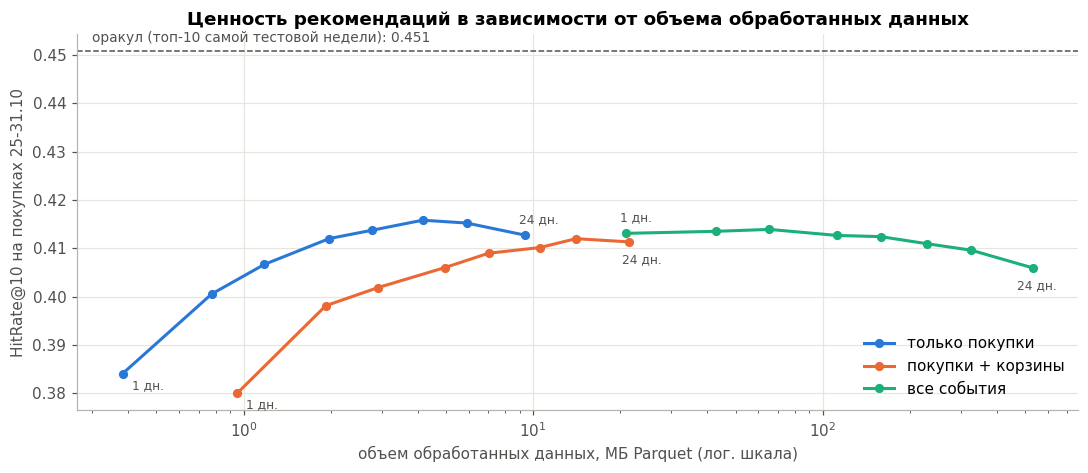

In [ ]:
# Ценность от объема: HitRate@10 на покупках 25-31.10 при разной глубине истории и разных типах событий
T0 = '2019-10-25'
con.execute(f"""CREATE OR REPLACE TEMP TABLE test_buys AS
                SELECT category_id, product_id FROM ev WHERE event_type = 'purchase' AND event_time >= TIMESTAMP '{T0}'""")
curve = []
for days in [1, 2, 3, 5, 7, 10, 14, 24]:
    for sig, filt in [('только покупки', "event_type = 'purchase'"), ('покупки + корзины', "event_type <> 'view'"),
                      ('все события', 'true')]:
        r = con.sql(f"""
            WITH tr AS (SELECT category_id, product_id, count(*) AS sc FROM ev
                        WHERE event_time >= TIMESTAMP '{T0}' - INTERVAL {days} DAY AND event_time < TIMESTAMP '{T0}' AND {filt}
                        GROUP BY 1, 2),
                 top AS (SELECT * FROM tr QUALIFY row_number() OVER (PARTITION BY category_id ORDER BY sc DESC, product_id) <= 10)
            SELECT avg((top.product_id IS NOT NULL)::INT) AS hr,
                   (SELECT count(*) FROM ev WHERE event_time >= TIMESTAMP '{T0}' - INTERVAL {days} DAY
                                            AND event_time < TIMESTAMP '{T0}' AND {filt}) AS rows
            FROM test_buys LEFT JOIN top USING (category_id, product_id)
        """).fetchone()
        curve.append({'дней истории': days, 'сигнал': sig, 'HitRate@10': r[0], 'событий': r[1],
                      'Parquet, МБ': r[1] * BYTES_PER_ROW_PQ / 2**20})
curve = pd.DataFrame(curve)
display(curve.pivot(index='дней истории', columns='сигнал', values='HitRate@10').round(4))



# Границы для проверки: случайные 10 товаров категории и "оракул" (топ-10 по покупкам самой тестовой недели)
bounds = q(f"""
    WITH cat AS (SELECT category_id, count(DISTINCT product_id) AS n_prod FROM ev
                 WHERE event_time >= TIMESTAMP '{T0}' - INTERVAL 7 DAY AND event_time < TIMESTAMP '{T0}' GROUP BY 1),
         orc AS (SELECT category_id, product_id FROM test_buys GROUP BY 1, 2
                 QUALIFY row_number() OVER (PARTITION BY category_id ORDER BY count(*) DESC, product_id) <= 10)
    SELECT avg(coalesce(least(10, n_prod) / n_prod, 0)) AS random_hr,
           (SELECT avg((o.product_id IS NOT NULL)::INT) FROM test_buys t LEFT JOIN orc o USING (category_id, product_id)) AS oracle_hr,
           median(n_prod) AS median_products_in_category_of_purchase
    FROM test_buys LEFT JOIN cat USING (category_id)
""")
display(bounds.round(4))

fig, ax = plt.subplots(figsize=(10, 4.4))
ax.axhline(bounds.oracle_hr[0], color='#52514e', linewidth=1, linestyle='--')
ax.text(0.3, bounds.oracle_hr[0] + 0.002, f'оракул (топ-10 самой тестовой недели): {bounds.oracle_hr[0]:.3f}', color='#52514e', fontsize=9)
for i, sig in enumerate(['только покупки', 'покупки + корзины', 'все события']):
    d = curve[curve['сигнал'] == sig]
    ax.plot(d['Parquet, МБ'], d['HitRate@10'], marker='o', markersize=5, color=COLORS[i], label=sig)
    offsets = {'только покупки': [(6, -10), (-4, 8)], 'покупки + корзины': [(6, -10), (-4, -14)],
               'все события': [(-4, 8), (-10, -14)]}[sig]
    for (_, pt), off in zip(d.iloc[[0, -1]].iterrows(), offsets):
        ax.annotate(f"{int(pt['дней истории'])} дн.", (pt['Parquet, МБ'], pt['HitRate@10']),
                    xytext=off, textcoords='offset points', fontsize=8, color='#52514e')
ax.set_xscale('log')
ax.set_xlabel('объем обработанных данных, МБ Parquet (лог. шкала)')
ax.set_ylabel('HitRate@10 на покупках 25-31.10')
ax.set_title('Ценность рекомендаций в зависимости от объема обработанных данных')
ax.legend(loc='lower right')
savefig('p5_value_volume')

**Ответ на вопрос «20% данных дают 80% ценности?»:** распределение ещё жёстче, чем 80/20. Продавался только каждый четвёртый товар (42 241 из 166 794). Топ-20% продаваемых товаров дают 96,7% выручки, а 80% выручки приходится всего на 546 товаров (1,3% продаваемых). Класс C, 36 670 товаров (87%), приносит 5% выручки.

По объёму данных картина похожая. Лучший HitRate@10 (0,416) даёт 10 дней одних покупок, это около 4 МБ Parquet. Просмотры (96% объёма) заметно помогают только на очень короткой истории: за 1 день все события дают 0,413 против 0,384 у одних покупок. Дальше покупки догоняют, а длинная история всех событий ухудшает качество (0,406 на 24 днях, около 550 МБ): старые просмотры тянут в выдачу вчерашние популярные товары.

Высокий HitRate проверен границами. Случайные 10 товаров категории дают 0,028, а оракул, который знает покупки самой тестовой недели, 0,451. Правило «популярное в категории» почти упирается в потолок, потому что спрос сосредоточен в сотнях товаров. Есть допущение: метрика считает категорию покупки известной, как будто пользователь уже находится на странице категории.

**Ответ на вопрос «какие данные можно не обрабатывать»:** просмотры старше 1-3 дней для этой модели, 10,6% событий (просмотры товаров, которые не продавались ни разу) для расчёта популярности, события ботов. Просмотры за несколько последних дней нужны: они закрывают холодный старт новых товаров и дают признаки текущей сессии.

**Предложение по приоритизации данных:** 1) покупки и корзины, полностью и с проверкой качества; 2) просмотры последних 1-3 дней и текущей сессии в реальном времени; 3) история просмотров только в холодном хранилище для экспериментов.

### 4) Предложите стратегию мониторинга ценности данных после запуска системы:
- Какие метрики отслеживать?
- Как часто пересчитывать ROI?

Главная метрика сценария (средний чек) оценивается A/B-тестом. Длительность теста считаю по разбросу суммы заказов октября.

In [ ]:
# Сколько заказов нужно в каждой группе A/B-теста, чтобы увидеть рост среднего чека (alpha = 0.05, мощность 0.8)
from scipy.stats import norm
sigma = orders.std()
z = norm.ppf(1 - 0.05 / 2) + norm.ppf(0.8)
ab = pd.DataFrame({'рост среднего чека, %': [1, 2, 5, 10, 15]})
ab['заказов на группу'] = np.ceil(2 * (z * sigma / (AVG_CHECK * ab['рост среднего чека, %'] / 100)) ** 2).astype(int)
ab['дней при 50/50 трафика'] = ab['заказов на группу'] / (biz.buy_sessions / DAYS / 2)
print(f'Средний чек {AVG_CHECK:.2f}, стандартное отклонение суммы заказа {sigma:.2f}')
display(ab.round(2))

Средний чек 365.27, стандартное отклонение суммы заказа 506.02


,"рост среднего чека, %",заказов на группу,дней при 50/50 трафика
0,1,301273,29.670
1,2,75319,7.420
2,5,12051,1.190
3,10,3013,0.300
4,15,1339,0.130


**Ответ на вопрос «какие метрики отслеживать»:**
- бизнес: средний чек и его медиана в тестовой и контрольной группах, товаров в заказе, конверсия сессии в покупку (не должна падать), выручка на посетителя;
- модель: HitRate@10 и CTR рекомендаций, доля выдачи из товаров класса A, покрытие каталога;
- данные: объём потока против типичного для времени суток, задержка признаков (lag Kafka), доля дублей и пропусков, результаты Great Expectations;
- затраты: счёт Yandex Cloud по сервисам.

**Ответ на вопрос «как часто пересчитывать ROI»:** раз в месяц по итогам месяца и после каждого крупного изменения модели. Разброс суммы заказа большой (стандартное отклонение 506 у.е. при среднем 365), поэтому рост на 1% надёжно виден только примерно через 30 дней теста при делении трафика 50/50. Рост на 5% и больше статистически заметен уже через 1-2 дня, но тест всё равно должен идти не меньше двух полных недель, чтобы покрыть недельный цикл и эффект новизны. Раньше этого срока пересчитывать ROI бессмысленно, результат будет шумом.

### 5) Оцените, как изменится ценность данных через 1 год (учитывая конкуренцию, изменения в бизнесе)

Ценность накопленных данных со временем падает: ассортимент и спрос меняются. Меряю это прямо: модель обучается на 7 днях, но окно обучения отодвигается в прошлое на 0-17 дней, а тест остаётся тем же (покупки 25-31 октября).

Потеря качества при устаревании данных: 0.52% в день (половина за 133 дней)


,"возраст данных, дней",HitRate@10,"к свежей модели, %"
0,0,0.412,100.000
1,3,0.408,98.859
2,7,0.401,97.300
3,10,0.389,94.196
4,14,0.382,92.639
5,17,0.380,92.242


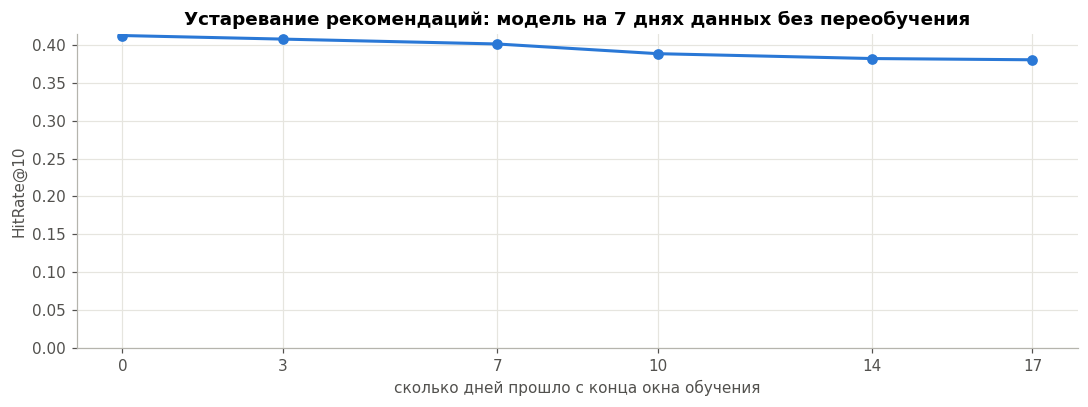

In [ ]:
# Устаревание модели: обучение на 7 днях, тест на покупках 25-31.10; окно обучения сдвигается в прошлое
decay = []
for lag in [0, 3, 7, 10, 14, 17]:
    end = pd.Timestamp(T0) - pd.Timedelta(days=lag)
    start = end - pd.Timedelta(days=7)
    r = con.sql(f"""
        WITH tr AS (SELECT category_id, product_id, count(*) AS sc FROM ev
                    WHERE event_time >= TIMESTAMP '{start}' AND event_time < TIMESTAMP '{end}' GROUP BY 1, 2),
             top AS (SELECT * FROM tr QUALIFY row_number() OVER (PARTITION BY category_id ORDER BY sc DESC, product_id) <= 10)
        SELECT avg((top.product_id IS NOT NULL)::INT) FROM test_buys LEFT JOIN top USING (category_id, product_id)
    """).fetchone()[0]
    decay.append({'возраст данных, дней': lag, 'HitRate@10': r})
decay = pd.DataFrame(decay)
decay['к свежей модели, %'] = 100 * decay['HitRate@10'] / decay['HitRate@10'].iloc[0]
b_, a_ = np.polyfit(decay['возраст данных, дней'], np.log(decay['HitRate@10']), 1)
print(f'Потеря качества при устаревании данных: {100 * (1 - math.exp(b_)):.2f}% в день '
      f'(половина за {math.log(2) / -b_:.0f} дней)' if b_ < 0 else 'Качество не падает с возрастом данных')
display(decay.round(4))

fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(decay['возраст данных, дней'], decay['HitRate@10'], marker='o', markersize=6, color=COLORS[0])
ax.set_xticks(decay['возраст данных, дней'])
ax.set_xlabel('сколько дней прошло с конца окна обучения')
ax.set_ylabel('HitRate@10')
ax.set_title('Устаревание рекомендаций: модель на 7 днях данных без переобучения')
ax.set_ylim(0, None)
savefig('p5_decay')

**Ответ на вопрос «как изменится ценность данных через год»:** модель без переобучения теряет около 0,5% качества в день: через 17 дней HitRate падает с 0,412 до 0,380 (-8%). Продлевать эту экспоненту на год ненадёжно, потому что спрос на самые популярные товары держится дольше. Но направление однозначное: ценность конкретных событий живёт недели, а не годы.

Через год:
- **старые данные:** события октября почти ничего не дадут модели: ассортимент и цены сменятся, а для рекомендаций хватает 1-10 последних дней. Сохранят ценность покупки для сезонности (ноябрьская распродажа, Новый год) и для оценки LTV;
- **конвейер данных** сохранит ценность, если модель переобучается ежедневно;
- **конкуренция:** когда такие же рекомендации есть у конкурентов, прирост к среднему чеку от простой популярности уменьшается. Преимущество даёт персонализация на признаках сессии, для которой и нужен поток;
- **изменения в бизнесе:** при росте магазина объём растёт медленно (Часть 1), а ценность растёт вместе с выручкой, поэтому ROI со временем только улучшается.

**Вывод о том, оправданы ли затраты:** да. Затраты первого года (12,25 млн ₽) окупаются уже при росте среднего чека на 0,026%, а цель сценария 15%. Основная ценность сосредоточена в малой части данных: покупках за последние 10 дней и 546 товарах класса A. Просмотры нужны в основном свежие, поэтому затраты на хранение и обработку истории можно держать минимальными. Единственный способ подтвердить эффект это A/B-тест.

## Часть 6: Выбор технологий и рекомендации

### 1) На основе анализа 5V предложите технологический стек:
- Для хранения данных (S3, HDFS, Delta Lake)
- Для обработки (Spark, Flink, Kafka Streams)
- Для ML (MLflow, Feature Store)
- Для оркестрации (Airflow, Prefect)

Стек подобран под найденные ограничения. Volume небольшой (8 ГБ в год в Parquet), Velocity средняя, но нужна свежесть в секунды (16-116 событий/с, пауза в сессии от 18 с), Variety низкая, по Veracity критичны цены, Value сосредоточена в свежих данных.

| Задача | Выбор | Для чего |
|---|---|---|
| Приём событий | Yandex Managed Kafka + Schema Registry (Avro) | буфер на 7 дней, контракт схемы событий |
| Хранение | Object Storage (S3) + Delta Lake поверх Parquet zstd | озеро данных с ACID, MERGE для дедупликации и справочников |
| Обработка | Spark: пакетная обработка и Structured Streaming | один движок для обучения и признаков сессии |
| Онлайн-признаки | Valkey (Redis) | признаки сессии и списки кандидатов за единицы миллисекунд |
| ML | MLflow (эксперименты, реестр моделей) + Feast (Feature Store) | версии моделей, одинаковые признаки в обучении и в сервисе |
| Сервис рекомендаций | Python-сервис (FastAPI) на 2 ВМ | ответ < 100 мс |
| Оркестрация | Yandex Managed Airflow | ежедневное обучение, проверки качества, обслуживание таблиц |
| Качество данных | Great Expectations | проверка суточного пакета до переобучения |

### 2) Обоснуйте выбор каждой технологии с точки зрения:
- Как она решает проблемы, выявленные в анализе 5V
- Какие у нее ограничения в вашем сценарии
- Какие альтернативы вы рассматривали и почему от них отказались

| Технология | Какую проблему 5V решает | Ограничения в сценарии | Альтернативы и почему отказались |
|---|---|---|---|
| Kafka + Schema Registry | Velocity: буфер переживает сбой потребителя (30 минут это до 7,3 МБ, 7 дней около 0,5 ГБ в Avro). Veracity: схема отсекает события без обязательных полей | три брокера для 16 событий/с загружены на доли процента, их держим ради отказоустойчивости; стоимость 15 тыс. ₽ в месяц | прямая запись в S3: при сбое хранилища события теряются, нет повторного чтения потока |
| Object Storage + Delta Lake | Volume: Parquet zstd в 8 раз компактнее CSV, классы хранения для архива. Veracity: MERGE удаляет 0,07% дублей идемпотентно. Variety: строгая схема и справочники | мелкие файлы от потока нужно регулярно уплотнять (OPTIMIZE) | HDFS: свой кластер ради 8 ГБ в год не окупается. Iceberg: равноценен, но Delta проще подключается к Spark |
| Spark (batch + Structured Streaming) | Velocity: микробатчи по 1-2 с укладываются в требование свежести меньше 18 с. Value: обучение на истории тем же кодом | задержка 0,5-2 с, для задач с порогом 10-50 мс не подойдёт; для 8 ГБ в год пакетная часть избыточна по объёму | Flink: задержка меньше 10 мс здесь не нужна, а второй движок усложняет поддержку. Kafka Streams: только JVM. Pandas: месяц занимает в памяти 14-34 ГБ с запасом на операции (Часть 1) |
| Valkey | Velocity: чтение признаков за доли миллисекунды, оставляет запас в бюджете 100 мс | данные в памяти: признаки 3 млн пользователей по ~200 байт это около 0,6 ГБ, помещаются с запасом | Cassandra: нужна при терабайтах онлайн-данных, здесь избыточна. Чтение из S3 при каждом запросе: сотни миллисекунд |
| MLflow + Feast | Value: версии моделей и откат при падении HitRate; одинаковые признаки в обучении и в сервисе | Feast добавляет ещё один компонент, для первой модели можно обойтись без него | Писать признаки вручную в двух местах: главная причина расхождения офлайн- и онлайн-качества |
| Airflow | Veracity: проверки качества до переобучения, повтор при сбое. Value: ежедневное переобучение против устаревания 0,5% в день | управляемый Airflow дороже ВМ (9,7 тыс. ₽ в месяц) | Prefect: в Yandex Cloud нет управляемого сервиса, пришлось бы держать самим. Cron: нет зависимостей и повторов |
| Great Expectations | Veracity: ловит нулевые цены, дубли и пропуски до того, как они испортят средний чек | медленный на больших пакетах, поэтому в потоке только лёгкие проверки | самописные SQL-проверки: работают, но без отчётов и истории |

### 3) Предложите архитектуру системы:
- Схема обработки данных (можно нарисовать в Mermaid)
- Оценка требуемых ресурсов
- План миграции с текущего состояния

**Схема обработки данных:**

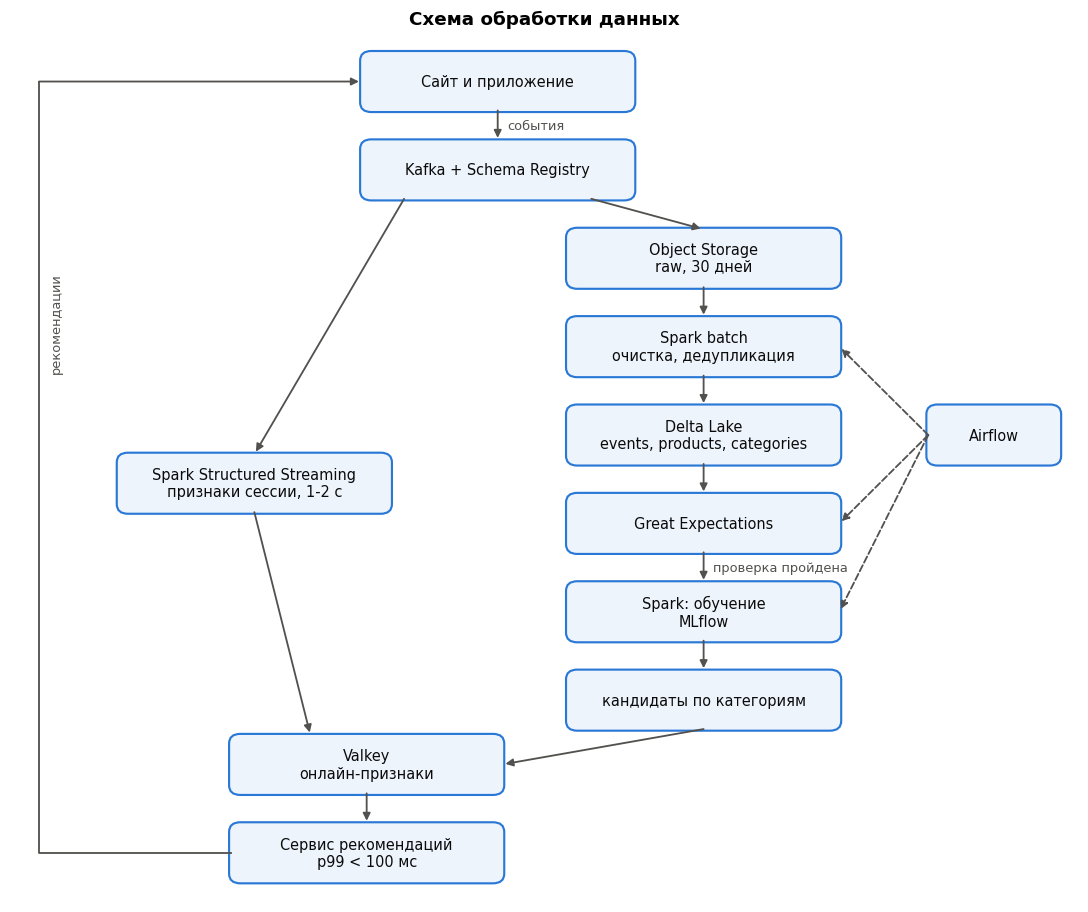

In [ ]:
from matplotlib.patches import FancyBboxPatch

W, H = 2.9, 0.72
nodes = {
    'site': (5.0, 10.0, 'Сайт и приложение'),
    'kafka': (5.0, 8.9, 'Kafka + Schema Registry'),
    'stream': (2.4, 5.0, 'Spark Structured Streaming\nпризнаки сессии, 1-2 с'),
    'raw': (7.2, 7.8, 'Object Storage\nraw, 30 дней'),
    'batch': (7.2, 6.7, 'Spark batch\nочистка, дедупликация'),
    'delta': (7.2, 5.6, 'Delta Lake\nevents, products, categories'),
    'ge': (7.2, 4.5, 'Great Expectations'),
    'train': (7.2, 3.4, 'Spark: обучение\nMLflow'),
    'cand': (7.2, 2.3, 'кандидаты по категориям'),
    'valkey': (3.6, 1.5, 'Valkey\nонлайн-признаки'),
    'api': (3.6, 0.4, 'Сервис рекомендаций\np99 < 100 мс'),
    'airflow': (10.3, 5.6, 'Airflow'),
}
width = {k: (1.4 if k == 'airflow' else W) for k in nodes}

def edge(k, side):
    x, y, _ = nodes[k]
    return {'top': (x, y + H / 2), 'bottom': (x, y - H / 2),
            'left': (x - width[k] / 2, y), 'right': (x + width[k] / 2, y)}[side]

fig, ax = plt.subplots(figsize=(10, 8.4))
ax.set_xlim(-0.2, 11.2)
ax.set_ylim(-0.2, 10.6)
ax.axis('off')
for k, (x, y, label) in nodes.items():
    ax.add_patch(FancyBboxPatch((x - width[k] / 2, y - H / 2), width[k], H, boxstyle='round,pad=0.02,rounding_size=0.12',
                                facecolor='#eef4fc', edgecolor=COLORS[0], linewidth=1.4))
    ax.text(x, y, label, ha='center', va='center', fontsize=9.5, color='#0b0b0b')

def arrow(p1, p2, dashed=False):
    ax.annotate('', xy=p2, xytext=p1, arrowprops=dict(arrowstyle='-|>', color='#52514e', lw=1.2,
                                                      linestyle='--' if dashed else '-', shrinkA=0, shrinkB=2))

arrow(edge('site', 'bottom'), edge('kafka', 'top'))
ax.text(5.1, 9.45, 'события', fontsize=8.5, color='#52514e', va='center')
arrow((4.0, 8.9 - H / 2), edge('stream', 'top'))
arrow((6.0, 8.9 - H / 2), edge('raw', 'top'))
for a, b in [('raw', 'batch'), ('batch', 'delta'), ('delta', 'ge'), ('ge', 'train'), ('train', 'cand')]:
    arrow(edge(a, 'bottom'), edge(b, 'top'))
ax.text(7.3, 3.95, 'проверка пройдена', fontsize=8.5, color='#52514e', va='center')
arrow(edge('cand', 'bottom'), edge('valkey', 'right'))
arrow(edge('stream', 'bottom'), (3.0, 1.5 + H / 2))
arrow(edge('valkey', 'bottom'), edge('api', 'top'))
for t in ['batch', 'ge', 'train']:
    arrow(edge('airflow', 'left'), edge(t, 'right'), dashed=True)
x0 = 0.1
ax.plot([edge('api', 'left')[0], x0, x0], [0.4, 0.4, 10.0], color='#52514e', lw=1.2)
arrow((x0, 10.0), edge('site', 'left'))
ax.text(x0 + 0.12, 7.0, 'рекомендации', rotation=90, fontsize=8.5, color='#52514e', va='center')
ax.set_title('Схема обработки данных')
savefig('p6_architecture')

In [ ]:
display(infra.assign(**{'₽ в год': infra['₽ в месяц'] * 12}).round(0))
print(f'Итого: {infra_month:,.0f} ₽ в месяц; на пике сервису рекомендаций нужно '
      f'{int(res_cap.iloc[2]["vCPU (c)"])} vCPU, с десятикратным запасом {int(res_cap.iloc[3]["vCPU (c)"])} vCPU')

,статья,₽ в месяц,₽ в год
0,Kafka: 3 брокера 2 vCPU / 8 ГБ,15 466.000,185 587.000
1,Spark Structured Streaming: 2 ВМ 4 vCPU / 16 ГБ,14 746.000,176 947.000
2,Сервис рекомендаций: 2 ВМ 2 vCPU / 4 ГБ,5 472.000,65 664.000
3,Valkey (online features): 2 хоста 2 vCPU / 8 ГБ,10 310.000,123 725.000
4,"Spark: обучение 2 ч в сутки, 16 vCPU / 64 ГБ",3 099.000,37 191.000
5,Airflow: 2 vCPU / 8 ГБ,9 725.000,116 702.000
6,"Object Storage (среднее за год, стандартное + холодное)",5.000,54.000


Итого: 58,823 ₽ в месяц; на пике сервису рекомендаций нужно 1 vCPU, с десятикратным запасом 7 vCPU


**Оценка требуемых ресурсов:** около 59 тыс. ₽ в месяц на инфраструктуру. На пике сервису рекомендаций хватает 1 vCPU (Часть 2), ставится 2 экземпляра по 2 vCPU ради отказоустойчивости. При десятикратном росте нагрузки нужно 7 vCPU, это добавление ВМ без смены архитектуры. Хранение года данных стоит меньше 100 ₽.

**План миграции с текущего состояния.** Сейчас данные выгружаются помесячными CSV. Переход идёт так, чтобы старый путь работал до конца проверки нового:
1. Исторические CSV переводятся в Delta Lake: месяц конвертируется за 1-3 минуты (Часть 1), дубли удаляются, справочники заполняются.
2. Сайт начинает писать события в Kafka параллельно со старой выгрузкой. Две недели сверяем число событий по дням между старым и новым путём.
3. Первая модель (популярное в категории) считается раз в сутки и отдаётся через Valkey. Ей не нужен поток, но она уже даёт HitRate@10 около 0,41.
4. Подключаются признаки сессии из Spark Structured Streaming и персонализированная модель.
5. Старая выгрузка CSV отключается после месяца без расхождений.

### 4) Определите критические точки риска в вашем решении и способы их минимизации

| Риск | Откуда виден | Как снизить |
|---|---|---|
| Ошибка масштаба цены искажает средний чек | 1% записей x100 даёт +99% к чеку (Часть 4) | проверка цены против обычной цены товара, отчёт с медианой рядом со средним |
| Сбой сбора событий | 15 сбоев за октябрь, 315 минут и около 130 тыс. событий (Часть 4) | буфер Kafka на 7 дней, алерт на объём с учётом времени суток |
| Дубли событий | 30 220 полных дублей, почти все корзины | идентификатор события на клиенте, MERGE в Delta Lake |
| Боты искажают популярность | пользователь с 7 436 событиями в 7 400 сессиях | фильтр по числу событий и сессий из одного события |
| Устаревание модели | -0,5% HitRate в день без переобучения | ежедневное обучение в Airflow, алерт на падение HitRate |
| Холодный старт | 35% сессий из одного события, 75% товаров без продаж | популярное в категории как запасная выдача, свежие просмотры в признаках |
| Эффект не подтвердится | ROI держится на допущении о росте чека | A/B-тест с заранее рассчитанной длительностью, контроль конверсии |
| Рост нагрузки | распродажи дают кратные пики | горизонтальное масштабирование сервиса, 7 vCPU на десятикратный пик |

### 5) Составьте roadmap внедрения на 6 месяцев с четкими этапами и метриками успеха

| Месяц | Этап | Метрика успеха |
|---|---|---|
| 1 | Object Storage и Delta Lake, загрузка истории, ежедневные проверки Great Expectations | вся история загружена, дублей 0, проверки проходят в 95% дней |
| 2 | Kafka и Schema Registry, параллельная запись событий | расхождение с выгрузкой CSV меньше 0,1% событий в день, lag меньше 5 с |
| 3 | Базовая модель «популярное в категории» в сервисе через Valkey | офлайн HitRate@10 не ниже 0,41, p99 ответа меньше 100 мс |
| 4 | Признаки сессии в Spark Structured Streaming, MLflow, персонализированная модель | свежесть признаков p95 меньше 5 с, офлайн HitRate@10 выше базовой модели |
| 5 | A/B-тест на части трафика | рост среднего чека статистически значим, конверсия не ниже контрольной |
| 6 | Полный запуск, мониторинг и ежемесячный пересчёт ROI | средний чек +15% к контролю или зафиксирован фактический эффект с планом доработок |

**Вывод о том, как решение учитывает 5V и бизнес-требования:**
- Volume: Parquet zstd и классы хранения держат год данных в 8 ГБ и меньше 100 ₽; Spark нужен как общий движок, а не из-за объёма.
- Velocity: Kafka и Spark Structured Streaming обновляют признаки сессии за секунды, Valkey и лёгкий сервис укладываются в 100 мс на 1-2 vCPU.
- Variety: строгая схема Delta Lake и справочники товаров и категорий; разбор текста и геоданных не нужен.
- Veracity: Schema Registry, дедупликация через MERGE, Great Expectations до переобучения и контроль объёма потока.
- Value: свежие покупки и просмотры дают почти всю ценность, затраты окупаются при росте чека на сотые доли процента, а сам рост проверяется A/B-тестом.

## Общие выводы

1. Проблема этих данных не в объёме: месяц весит 5,28 ГБ в CSV и 0,66 ГБ в Parquet zstd, до 1 ТБ при текущем темпе 16 лет. Хранение года стоит меньше 100 ₽.
2. Определяющий фактор здесь Velocity: пауза между действиями в сессии 18-68 с, поэтому признаки сессии нужно обновлять потоком за секунды, а пакетная обработка остаётся для обучения.
3. Данные структурированные и достаточно чистые (дублей 0,07%, обязательные поля заполнены). Опасны ошибки масштаба цены и сбои сбора: 1% неверных цен удваивает средний чек.
4. Ценность сосредоточена в малой части данных: 546 товаров дают 80% выручки, 10 дней покупок дают лучший HitRate@10 (0,416), а история просмотров длиннее нескольких дней качество не повышает.
5. Затраты первого года 12,25 млн ₽ окупаются при росте среднего чека на 0,03%, поэтому проект оправдан; реальность эффекта нужно подтвердить A/B-тестом.